# **Problem Statement**

## Business Context

In last-mile logistics, roughly 10% of all shipments encounter delivery exceptions - failed attempts, address mismatches, damaged packages, refused deliveries, and weather delays. Each failed delivery costs in direct reattempt expenses, while the downstream impact is far steeper: consumers stop shopping with a retailer after just 2-3 failed deliveries, and supply chain disruptions cost companies millions per year.

Despite these costs, most organizations still handle exception triage and resolution manually. Operations staff read through status logs and messy driver notes, cross-reference customer profiles and internal playbooks, decide on a resolution action, and draft customer notifications - all under time pressure. Teams rely on support tickets, tribal knowledge, and rigid rule engines that cannot handle the nuanced, multi-factor judgment calls that real exceptions demand. A VIP customer with a perishable package and a broken gate code on a second attempt requires a fundamentally different resolution than a standard customer's first failed attempt on a non-perishable item - but manual processes treat them with the same slow, inconsistent workflow.

Key KPIs affected include:
- Exception resolution time (constrained by manual triage throughput)
- Escalation accuracy (missed or unnecessary supervisor escalations)
- Customer communication quality and personalization
- Cost per exception (reattempt costs, spoilage write-offs, unnecessary truck rolls)
- Customer retention and lifetime value

If unaddressed, logistics providers face rising exception-handling costs, inconsistent service quality, preventable customer churn, and loss of competitive ground to players who are already investing in AI-powered exception detection and response automation.

By applying an AI-powered multi-agent system that ingests delivery logs, cross-references customer profiles and locker availability, retrieves resolution policy from an operational playbook, and generates validated decisions with personalized customer communications, logistics providers can automate the full exception-handling pipeline from detection through resolution, with built-in quality validation and supervisor escalation where policy requires it.


## Objective

The objective is to build a POC of an AI-powered multi-agent delivery exception handling system for the last-mile delivery operations of a mid-sized retailer that:
- uses the operator's available data to process exceptions end-to-end,
- ingests raw delivery status logs, including noisy, duplicated, and multi-row shipment events, and correctly identifies actionable exceptions versus routine operational noise,
- decides the appropriate resolution action (reschedule, reroute to locker, replace, or return to sender) by reasoning over playbook rules, customer context, package constraints, and locker eligibility, while respecting operational policies around perishable handling, fragile thresholds, and locker capacity.
- escalates to a human supervisor when policy requires it and avoids unnecessary escalations that waste supervisor capacity,
- generates personalized customer notifications with tone, channel, and content calibrated to customer tier and exception severity, and
- produces auditable decisions with step-by-step rationale, critical validation traces, and system evaluation metrics across five dimensions: task completion rate, escalation accuracy, tool call accuracy, reasoning trajectory coherence, and end-to-end latency.

The end goal is to demonstrate measurable accuracy and consistency on curated exception scenarios sufficient to justify scaling the approach to real-time operations with live delivery feeds, broader exception taxonomies, and multi-region deployment.


## Data Dictionary

The data comprises three types of files.

### SQLite Database (`customers.db`)

**Table: `customers`** - 12 records

| Attribute | Type | Values / Description |
|:---|:---|:---|
| customer_id | string | Primary key (`CUST-001` to `CUST-012`), Foreign key in delivery logs |
| name | string | Customer full name (**PII**) |
| tier | string | STANDARD, PREMIUM, VIP |
| preferred_channel | string | SMS, EMAIL |
| exceptions_last_90d | integer | Range: 0-6 |
| active_credit | float | Range: \$0.00-\$20.00 |

**Table: `lockers`** - 6 records

| Attribute | Type | Values / Description |
|:---|:---|:---|
| locker_id | string | Primary key (`LOC-001` to `LOC-006`) |
| address | string | Locker street address |
| zip_code | string | 10001-10006 |
| capacity_status | string | AVAILABLE, LIMITED, FULL |
| operating_hours | string | e.g., "6AM-10PM" or "24 hours" |
| max_package_size | string | SMALL, MEDIUM, LARGE |

### CSV Files

**Delivery Status Logs (`delivery_logs.csv`)** - 13 rows, 10 unique shipments

| Attribute | Type | Values / Description |
|:---|:---|:---|
| shipment_id | string | `SHP-001` to `SHP-01`0, Multiple rows may share the same ID for multi-event shipments. |
| timestamp | datetime | ISO format |
| status_code | string | One of seven codes: DELIVERED, ATTEMPTED, DAMAGED, ADDRESS_ISSUE, REFUSED, WEATHER_DELAY, SCANNED |
| status_description | string | Free-text driver/handler notes |
| customer_id | string | Foreign key to `customers` table (`CUST-001` to `CUST-012`) |
| delivery_address | string | Full address including zip code |
| package_type | string | STANDARD, PERISHABLE, FRAGILE |
| package_size | string | SMALL, MEDIUM, LARGE |
| attempt_number | integer | 0 for pre-delivery scans, 1+ for delivery attempts |
| is_duplicate_scan | boolean | True for repeated scan events |

**Ground Truth Labels (`ground_truth.csv`)** - 13 rows, aligned 1:1 with delivery logs

| Attribute | Type | Values / Description |
|:---|:---|:---|
| shipment_id | string | Matches delivery logs (`SHP-001` to `SHP-010`) |
| is_exception | string | YES, NO |
| expected_resolution | string | RESCHEDULE, REPLACE, REROUTE_TO_LOCKER, RETURN_TO_SENDER, N/A |
| expected_tone | string | FORMAL, CASUAL, N/A |
| should_escalate | string | YES, NO, N/A |
| ground_truth_reasoning | string | Step-by-step justification tracing each label to specific playbook rules, customer attributes, and locker constraints |

### Exception Resolution Playbook (`exception_resolution_playbook.pdf`)

An internal operations manual for human dispatchers in natural language.

# **Please read the instructions carefully before starting the project.**

This is a Python Notebook file with blocks of code pre-filled in alignment with a possible solution for the business use case at hand, and some blank sections where the code has to be written from scratch.

* Please feel free to
    * leverage the pre-filled code blocks as they are, or
    * update the pre-filled code blocks to incorporate necessary changes as per your desired solution workflow for the business problem at hand, or
    * discard the pre-filled code blocks and write the entire code from scratch
* Notebook sections and code blocks that contain instructions and tasks to be performed are mentioned.
* Blanks '\_\_\_\_\_' are provided in the notebook that need to be filled with an appropriate code to get the correct result.
    * With every '\_\_\_\_\_' blank, there is a comment that briefly describes what needs to be filled in the blank space.
* Identify the task to be performed correctly, and only then proceed to write the required code.
* Please sequentially run the code cells from the beginning to avoid any unnecessary errors.
* Add the results/observations derived from the analysis under the respective notebook sections as per the grading rubric requirements.

# **Installing and Importing Necessary Libraries and Dependencies**

In [1]:
# !pip -q install \
#     langchain==1.2.10 \
#     langchain-openai==1.1.10 \
#     langgraph==1.0.8 \
#     langsmith==0.7.3 \
#     langchain-community==0.4.1 \
#     langchain-huggingface==1.2.0 \
#     openai==2.21.0 \
#     pandas==2.2.2 \
#     numpy==2.0.2 \
#     scikit-learn==1.6.1 \
#     sentence-transformers==5.2.3 \
#     pydantic==2.12.3 \
#     langchain-chroma \
#     langchain-text-splitters \
#     pypdf

**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for VSCode/Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

In [ ]:
# Standard library
import os
import csv
import json
import re
import sqlite3
import time
import statistics
import warnings
from collections import defaultdict
from typing import TypedDict, Annotated, List, Dict, Any, Optional, Tuple, Literal
from datetime import datetime, timedelta
from dataclasses import dataclass, fields

# Third-party — data and utilities
import pandas as pd
import numpy as np
import fitz                                          # PyMuPDF — PDF text extraction
import chromadb                                      # Vector database client
from pydantic import BaseModel, Field, model_validator
from dotenv import load_dotenv
from IPython.display import display, Image, Markdown

# LangChain — LLM framework
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import JsonOutputParser, StrOutputParser
from langchain_chroma import Chroma
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document

# LangGraph — agentic workflow orchestration
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command

warnings.filterwarnings("ignore", category=UserWarning)

# **LLM and Agent Observability Setup**

We load all OpenAI and LangSmith credentials from a secure `config.json` file and store them as environment variables.

In [3]:
# Load the JSON file and extract values
file_name = 'config.json'                                                       # Name of the configuration file
with open(file_name, 'r') as file:                                              # Open the config file in read mode
    config = json.load(file)                                                    # Load the JSON content as a dictionary

    OPENAI_API_KEY = config.get("OPENAI_API_KEY")                               # Extract OpenAI API key
    OPENAI_API_BASE = config.get("OPENAI_API_BASE")                             # Extract OpenAI base URL

    LANGCHAIN_TRACING_V2 = config.get("LANGCHAIN_TRACING_V2")                   # Extract LangSmith tracing flag
    LANGCHAIN_API_KEY = config.get("LANGCHAIN_API_KEY")                         # Extract LangSmith API key
    LANGCHAIN_PROJECT = config.get("LANGCHAIN_PROJECT")                         # Extract LangSmith project name


# Store OpenAI credentials in environment variables
os.environ['OPENAI_API_KEY'] = OPENAI_API_KEY                                   # Set OpenAI API key
os.environ['OPENAI_BASE_URL'] = OPENAI_API_BASE                                 # Set OpenAI API base URL


# Store LangSmith credentials in environment variables
os.environ['LANGCHAIN_TRACING_V2'] = LANGCHAIN_TRACING_V2                       # Enable LangSmith tracing
os.environ['LANGCHAIN_API_KEY'] = LANGCHAIN_API_KEY                             # Set LangSmith API key
os.environ['LANGCHAIN_PROJECT'] = LANGCHAIN_PROJECT                             # Set LangSmith project

In [4]:
LLM_MINI_MODEL = "gpt-4o-mini"
LLM_STANDARD_MODEL = "gpt-4o"

# Aliases used by agent and critic nodes throughout the pipeline
gen_llm = ChatOpenAI(model=LLM_MINI_MODEL, temperature=0) # Generation/resolution/communication agents
eval_llm = ChatOpenAI(model=LLM_STANDARD_MODEL, temperature=0) # Critic agents and coherence evaluator

Initialize LangSmith client to enable **tracing** and **evaluation** of the agentic workflow, with automatic fallback if configuration is unavailable.

In [5]:
from langsmith import traceable, Client
from langsmith.evaluation import evaluate

# Initialize LangSmith client
try:
    langsmith_client = Client()
    LANGSMITH_ENABLED = True
    print("LangSmith tracing enabled")
except:
    LANGSMITH_ENABLED = False
    print("LangSmith not configured - tracing disabled")

LangSmith tracing enabled


# **Data Loading and Vector Database Setup**

## Data Paths

In [6]:
DATA_PATH = os.path.join(os.path.dirname(__name__), "data")
CUSTOMER_DB_PATH = os.path.join(DATA_PATH, "customers.db")
DELIVERY_LOGS_PATH = os.path.join(DATA_PATH, "delivery_logs.csv")
GROUND_TRUTH_PATH = os.path.join(DATA_PATH, "ground_truth.csv")
EXCEPTIONS_PATH = os.path.join(DATA_PATH, "exception_resolution_playbook.pdf")

## Loading the CSV files

In [7]:
delivery_logs_df = pd.read_csv(DELIVERY_LOGS_PATH)

print("\n\033[1mDelivery Logs Dataset:\033[0m")
print(f"Rows: {delivery_logs_df.shape[0]}, Columns: {delivery_logs_df.shape[1]}")
delivery_logs_df.head()


Delivery Logs Dataset:
Rows: 13, Columns: 10


,shipment_id,timestamp,status_code,status_description,customer_id,delivery_address,package_type,package_size,attempt_number,is_duplicate_scan
0,SHP-001,2026-03-05T10:14:00,DELIVERED,"Left at front door, signed by resident",CUST-003,"27 Maple Drive, Greenfield, 10001",STANDARD,SMALL,1,False
1,SHP-002,2026-03-05T11:05:00,ATTEMPTED,Nobody home rang bell twice no answer left not...,CUST-001,"140 Birch Lane, Westdale, 10003",STANDARD,MEDIUM,1,False
2,SHP-002,2026-03-05T11:07:00,ATTEMPTED,Nobody home rang bell twice no answer left not...,CUST-001,"140 Birch Lane, Westdale, 10003",STANDARD,MEDIUM,1,True
3,SHP-003,2026-03-05T09:45:00,ADDRESS_ISSUE,cant find building 999 on this street asked ar...,CUST-005,"999 Oak Avenue, Riverside, 10002",STANDARD,SMALL,1,False
4,SHP-004,2026-03-05T08:30:00,DAMAGED,Box crushed on one side contents might be dama...,CUST-008,"12 Pine Road, Northgate, 10004",FRAGILE,LARGE,1,False


In [8]:
ground_truth_df = pd.read_csv(GROUND_TRUTH_PATH)

print("\n\033[1mGround Truth Dataset:\033[0m")
print(f"Rows: {ground_truth_df.shape[0]}, Columns: {ground_truth_df.shape[1]}")
ground_truth_df.head()


Ground Truth Dataset:
Rows: 13, Columns: 6


,shipment_id,is_exception,expected_resolution,expected_tone,should_escalate,ground_truth_reasoning
0,SHP-001,NO,NaN,NaN,NaN,Successful delivery. Monitoring agent should f...
1,SHP-002,YES,RESCHEDULE,FORMAL,YES,1st failed attempt for VIP customer with 5 exc...
2,SHP-002,NO,NaN,NaN,NaN,Duplicate scan of row 1. Monitoring agent shou...
3,SHP-003,YES,RESCHEDULE,CASUAL,NO,"Address not found. Standard customer, no prior..."
4,SHP-004,YES,REPLACE,FORMAL,YES,Damaged fragile package for VIP customer. Play...


## Loading the SQLite database

In [9]:
# Ensure database exists
if not os.path.exists(CUSTOMER_DB_PATH):
    raise FileNotFoundError(
        "Customer database not found. "
        "Please run setup_customer_database.py first."
    )

# Connect to database
conn = sqlite3.connect(CUSTOMER_DB_PATH)
conn.row_factory = sqlite3.Row
cursor = conn.cursor()

# Minimal safety check for required table
cursor.execute("""
    SELECT customer_id FROM customers
    """
)

assert cursor.fetchone() is not None, "customers table missing"
print("\n\033[1mCustomer database connected and verified\033[0m")


Customer database connected and verified


In [10]:
customer_df = pd.read_sql_query("SELECT * FROM customers", conn)
lockers_df = pd.read_sql_query("SELECT * FROM lockers", conn)

In [11]:
customer_df

,customer_id,name,tier,preferred_channel,exceptions_last_90d,active_credit
0,CUST-001,John Smith,VIP,EMAIL,5,15.0
1,CUST-002,Jane Doe,PREMIUM,EMAIL,2,0.0
2,CUST-003,Robert Johnson,STANDARD,SMS,0,0.0
3,CUST-004,Maria Garcia,VIP,EMAIL,1,10.0
4,CUST-005,David Wilson,STANDARD,SMS,0,0.0
5,CUST-006,Sarah Brown,PREMIUM,EMAIL,3,5.0
6,CUST-007,Michael Lee,STANDARD,SMS,1,0.0
7,CUST-008,Emily Davis,VIP,EMAIL,4,20.0
8,CUST-009,James Taylor,STANDARD,SMS,0,0.0
9,CUST-010,Lisa Anderson,PREMIUM,EMAIL,2,0.0


In [12]:
lockers_df

,locker_id,address,zip_code,capacity_status,operating_hours,max_package_size
0,LOC-001,"150 Main Street, Greenfield",10001,AVAILABLE,6AM-10PM,LARGE
1,LOC-002,"42 Oak Avenue, Riverside",10002,LIMITED,7AM-9PM,MEDIUM
2,LOC-003,"88 Elm Boulevard, Westdale",10003,FULL,24 hours,LARGE
3,LOC-004,"215 Pine Road, Northgate",10004,AVAILABLE,8AM-8PM,SMALL
4,LOC-005,"33 Cedar Lane, Eastport",10005,LIMITED,6AM-11PM,MEDIUM
5,LOC-006,"170 Birch Court, Southfield",10006,AVAILABLE,24 hours,LARGE


## Loading the PDF file

In [13]:
# --------------------------
# Step 1: Load PDF with PyMuPDF
# --------------------------
def load_pdf_with_pymupdf(pdf_path) -> list:
    """Extract text from a PDF and return LangChain Document objects."""
    documents = []

    with fitz.open(pdf_path) as doc:
        metadata = doc.metadata

        for page_num, page in enumerate(doc):
            text = page.get_text()

            if text.strip():
                documents.append(
                    Document(
                        page_content=text.strip(),
                        metadata={
                            "source": pdf_path,
                            "page": page_num + 1,
                            "total_pages": len(doc),
                            "title": metadata.get("title", ""),
                            "author": metadata.get("author", ""),
                        },
                    )
                )

    return documents


pdf_path = EXCEPTIONS_PATH
raw_documents = load_pdf_with_pymupdf(pdf_path)
print(f"\n\033[1mLoaded {len(raw_documents)} pages from PDF\033[0m")
print("\n\033[1mSample Document:\033[0m")
print(raw_documents[0].page_content)


Loaded 10 pages from PDF

Sample Document:
Last-Mile Delivery Operations 
Exception Resolution Playbook 
Internal Use Only - Operations Team 
Document Version: 3.1 
About This Playbook 
This playbook is your go-to reference when a delivery doesn’t go as planned. It covers the 
most common exceptions you’ll encounter on shift and tells you exactly what to do in each 
case. When in doubt, follow the steps here before escalating. If a situation isn’t covered, or if 
you’re unsure, flag it for your shift supervisor. 
A few ground rules before we get into the specifics: 
•​
Always check the customer’s account tier before deciding on a resolution. VIP and 
Premium customers have different SLA commitments than Standard customers. 
•​
Document everything. Whatever you decide, log the reason in the shipment notes. If it 
gets reviewed later, we need to understand why you made the call you did. 
•​
Time matters. The faster we resolve an exception, the less likely it is to turn into a 
complaint

## Creating Vector Database

I will use the **ChromaDB** platform to create a vector database for the Exception Resolution Playbook. This vector store will be established using the `chromadb` Python library, and I will retrieve collections through API calls, which offer an interface for managing and querying vector data. The playbook will be processed and embedded into the vector database to facilitate efficient retrieval of relevant information during the agent's reasoning process.

In [14]:
# Load .env from the project directory
load_dotenv(".env")

# Verify the values loaded
print("API Key:", os.getenv("CHROMA_API_KEY"))
print("Tenant:", os.getenv("CHROMA_TENANT"))
print("Database:", os.getenv("CHROMA_DATABASE"))

API Key: ck-9pSYX4DUoYqeMkxJcnk6tuFRogf91o8XLrVbMPPtBa98
Tenant: 58b641c1-93fb-4e97-978a-78d1a44feec3
Database: Exception_Resolution_Playbook


I set the **chunk size** to 1,500 characters with an **overlap** of 300 characters. This approach allows the playbook content to be divided into manageable sections while keeping most subsections intact within a single chunk. Additionally, it retains enough context for accurate retrieval during agent reasoning and ensures that any conditional logic at the boundaries of the chunks is captured in both adjacent sections.

In [15]:
# --------------------------
# Step 2: Split into chunks
# --------------------------
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1500,
    chunk_overlap=300,
    separators=["\n\n", "\n", ". ", " ", ""],
)

chunks = text_splitter.split_documents(raw_documents)
print(f"Split into {len(chunks)} chunks")

# --------------------------
# Step 3: Choose an embedding model
# --------------------------
embedding_model = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2",
    model_kwargs={"device": "cpu"},        # Use "cuda" if GPU available
    encode_kwargs={"normalize_embeddings": True},
)

# ============================================================
# 4. Connect to ChromaDB server and create/load the vector store
# ============================================================
COLLECTION_NAME = "Exception_Resolution_Playbook"

# --- Connect to ChromaDB Cloud ---
try:
    chroma_client = chromadb.CloudClient(
        api_key=os.getenv("CHROMA_API_KEY"),
        tenant=os.getenv("CHROMA_TENANT"),
        database=os.getenv("CHROMA_DATABASE"),
    )
    # Lightweight connectivity check
    chroma_client.heartbeat()
    print("Connected to ChromaDB Cloud.")
except Exception as e:
    raise ConnectionError(f"ChromaDB connection failed: {e}") from e

# --- Get or create collection (idempotent) ---
existing_collections = [c.name for c in chroma_client.list_collections()]

if COLLECTION_NAME in existing_collections:
    # Collection exists - wrap in LangChain Chroma without re-embedding
    vector_store = Chroma(
        client=chroma_client,
        collection_name=COLLECTION_NAME,
        embedding_function=embedding_model,
    )
    count = vector_store._collection.count()
    print(f"Loaded existing collection '{COLLECTION_NAME}' ({count} chunks).")
else:
    # Collection does not exist - create from document chunks
    vector_store = Chroma.from_documents(
        documents=chunks,
        embedding=embedding_model,
        client=chroma_client,
        collection_name=COLLECTION_NAME,
    )
    count = vector_store._collection.count()
    print(f"Created new collection '{COLLECTION_NAME}' ({count} chunks).")

retriever = vector_store.as_retriever(
    search_type="mmr",
    search_kwargs={
        "k": 5,
        "fetch_k": 20,
    },
)

Split into 17 chunks


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Connected to ChromaDB Cloud.
Loaded existing collection 'Exception_Resolution_Playbook' (22 chunks).


# **Defining Tools**

Let's define the tools to be used by the multi-agent system.

## Delivery Log Reader

This tool reads all delivery log rows from the CSV file into a list of dictionaries.

In [16]:
@tool("read_delivery_logs")
def read_delivery_logs() -> list[dict]:
    """Read all delivery log rows from CSV. Used by preprocessor only."""
    # Open the CSV and parse each row into a dictionary keyed by column headers
    with open(DELIVERY_LOGS_PATH, "r") as f:
        return list(csv.DictReader(f))

## Customer Profile Lookup

We first define a shared database connection for all tools.

In [17]:
# Shared read-only connection for all tools
db_conn = sqlite3.connect(CUSTOMER_DB_PATH)
db_conn.row_factory = sqlite3.Row

This tool fetches a customer profile from the SQLite database by customer ID.

- The `include_pii` flag controls whether the customer's name is included in the response.
- When set to `False` (default), the name field is removed before returning.
- This enforces data privacy at the tool level: only the Communication Agent requests PII for message personalization; all other agents receive the redacted profile.

In [18]:
@tool("lookup_customer_profile")
def lookup_customer_profile(customer_id: str, include_pii: bool = False) -> dict:
    """Fetch customer profile from SQLite. PII (name) only included when explicitly requested."""
    # Query the customer record by ID
    cursor = db_conn.cursor()
    cursor.execute("SELECT * FROM customers WHERE customer_id = ?", (customer_id,))
    row = cursor.fetchone()

    # Return empty dict if customer not found
    if row is None:
        return {}

    # Convert database row to dictionary
    profile = dict(row)

    # Redact customer name unless PII is explicitly requested
    if not include_pii:
        profile.pop("name", None)

    return profile

## Locker Availability Checker

This tool queries the SQLite database for lockers in the same zip code as the delivery address, then evaluates each locker's eligibility based on three constraints:
- package size must fit within the locker's maximum capacity,
- the locker cannot be full, and
- lockers with limited capacity only accept small packages.

Each locker is returned with an eligible flag and a human-readable reason explaining the decision.

In [19]:
@tool("check_locker_availability")
def check_locker_availability(zip_code: str, package_size: str) -> list[dict]:
    """Find compatible lockers in the same zip code. Returns eligibility with reasoning."""
    # Map package sizes to numeric levels for comparison
    size_hierarchy = {"SMALL": 1, "MEDIUM": 2, "LARGE": 3}
    pkg_level = size_hierarchy.get(package_size, 0)

    # Query lockers matching the delivery zip code
    cursor = db_conn.cursor()
    cursor.execute("SELECT * FROM lockers WHERE zip_code = ?", (zip_code,))
    rows = cursor.fetchall()

    results = []
    for row in rows:
        locker = dict(row)
        locker_max = size_hierarchy.get(locker["max_package_size"], 0)

        # Check constraint 1: package must fit within locker's max size
        if locker_max < pkg_level:
            locker["eligible"] = False
            locker["reason"] = f"Locker max {locker['max_package_size']} < package {package_size}"

        # Check constraint 2: locker must not be full
        elif locker["capacity_status"] == "FULL":
            locker["eligible"] = False
            locker["reason"] = "Locker is FULL"

        # Check constraint 3: limited lockers only accept small packages
        elif locker["capacity_status"] == "LIMITED" and package_size != "SMALL":
            locker["eligible"] = False
            locker["reason"] = "Locker is LIMITED - only SMALL packages accepted"

        # All constraints passed
        else:
            locker["eligible"] = True
            locker["reason"] = "Compatible"

        results.append(locker)

    return results

## Playbook Search

This tool searches the playbook vector store for chunks most relevant to the given query, and returns each chunk's text content along with its source page number.

- This metadata is used for document citation tracking in the evaluation output.

In [20]:
@tool("search_playbook")
def search_playbook(query: str) -> list[dict]:
    """Retrieve relevant playbook sections via vector search. Returns chunks with page metadata."""
    # Run similarity search against the ChromaDB vector store
    docs = retriever.invoke(query)

    # Return chunk content and page number for each retrieved document
    return [
        {"content": d.page_content, "page": d.metadata.get("page", "?")}
        for d in docs
    ]

## Escalation Rule Engine

This tool defines a fully deterministic escalation rule engine that evaluates hard-coded business rules without any LLM involvement.

It checks two categories of triggers:
- automatic triggers (third delivery attempt, VIP with high exception history, damaged perishables, perishable weather delays exceeding 4 hours, fraud-indicating addresses), and
- discretionary triggers (standard customers with unusually high exception counts, premium perishable weather delays).

Delay hours are parsed from free-text descriptions using regex to handle varied formats like "5hr", "5 hours", or "5.5hr".

In [21]:
@tool("check_escalation_rules")
def check_escalation_rules(customer_tier: str, exceptions_last_90d: int,
                            attempt_number: int, package_type: str,
                            status_code: str, status_description: str) -> dict:
    """Deterministic escalation rule engine. Evaluates hard-coded business rules."""
    # List to collect triggered rules for detailed output
    triggers = []

    # --- Automatic triggers ---

    # 3rd failed attempt triggers escalation regardless of customer tier
    if attempt_number >= 3:
        triggers.append("AUTOMATIC: 3rd failed delivery attempt")

    # VIP customers with 3+ exceptions in last 90 days
    if customer_tier == "VIP" and exceptions_last_90d >= 3:
        triggers.append(f"AUTOMATIC: VIP customer with {exceptions_last_90d} exceptions in 90d (>=3)")

    # Any damaged perishable package needs fast replacement decision
    if status_code == "DAMAGED" and package_type == "PERISHABLE":
        triggers.append("AUTOMATIC: Damaged perishable package")

    # Perishable with weather delay over 4 hours - item likely compromised
    if status_code == "WEATHER_DELAY" and package_type == "PERISHABLE":
        # Extract delay hours from free-text using regex (handles "5hr", "5 hours", "5.5hr")
        hour_matches = re.findall(r'(\d+(?:\.\d+)?)\s*(?:hr|hour|hours)', status_description.lower())
        if hour_matches:
            hours = float(hour_matches[0])
            if hours > 4:
                triggers.append(f"AUTOMATIC: Perishable with {hours}hr delay (>4hr threshold)")

    # Address issues suggesting potential fraud
    fraud_keywords = ["vacant", "demolished", "construction site", "empty lot"]
    if status_code == "ADDRESS_ISSUE" and any(kw in status_description.lower() for kw in fraud_keywords):
        triggers.append("AUTOMATIC: Potential fraud - address is vacant/demolished")

    # --- Discretionary triggers ---

    # Standard customer with unusually high exception count signals systemic issue
    if customer_tier == "STANDARD" and exceptions_last_90d > 5:
        triggers.append(f"DISCRETIONARY: Standard customer with {exceptions_last_90d} exceptions in 90d (>5)")

    # Premium customer with perishable in weather delay - borderline urgency
    if customer_tier == "PREMIUM" and package_type == "PERISHABLE" and status_code == "WEATHER_DELAY":
        triggers.append("DISCRETIONARY: Premium customer with perishable in weather delay")

    return {
        "has_triggers": len(triggers) > 0,                                       # Quick boolean check for any triggers
        "trigger_count": len(triggers),                                          # Total number of triggers found
        "triggers": triggers                                                     # Detailed list of trigger descriptions
    }

# **Multi-Agent Architecture**

Now, let's define the multi-agent system architecture.

## Multi-Agent System State and Sub-agent View

We start by defining the multi-agent state and agent view system.

- `UnifiedAgentState` carries all data through the LangGraph pipeline - every field across all agents lives here.
- To enforce data isolation, five typed view dataclasses define which fields each agent can read and write.
- The `project_into` utility function extracts only the fields in an agent's view from the global state.
- The `merge_back` utility function writes back only the fields that the agent is allowed to modify.

This ensures agents cannot access or overwrite data outside their designated scope.

In [22]:
class UnifiedAgentState(TypedDict):
    """State object passed through the LangGraph pipeline."""
    # Input
    raw_rows: list[dict]                                                        # Raw delivery log rows for this shipment
    shipment_id: str

    # Preprocessor output
    consolidated_event: dict                                                     # Deduplicated, consolidated event
    customer_profile: dict                                                       # Redacted profile for resolution
    customer_profile_full: dict                                                  # Full profile with PII for communication
    locker_availability: list[dict]                                              # Lockers in same zip
    playbook_context: list[dict]                                                 # Retrieved playbook chunks with page metadata
    escalation_signals: dict                                                     # Deterministic rule output
    noise_override: bool                                                         # Preprocessor guardrail flag for routine noise
    guardrail_triggered: bool                                                    # True if input injection detected

    # Resolution Agent output
    resolution_output: dict                                                      # {is_exception, resolution, rationale}

    # Critic - resolution validation
    critic_resolution_output: dict                                               # {decision, rationale}
    resolution_revision_count: int                                               # Track retries, max 2
    critic_feedback: str                                                         # Feedback for revision loop

    # Communication Agent output
    communication_output: dict                                                   # {tone_label, communication_message}

    # Critic - communication validation
    critic_communication_output: dict                                            # {decision, rationale}

    # Routing
    next_agent: str                                                              # Next node to route to
    max_loops: int                                                               # Max revision loops

    # Final
    escalated: bool                                                              # Whether any critic node returned ESCALATE
    tool_calls_log: list[str]                                                    # Log of all tool invocations
    trajectory_log: list[str]                                                    # Audit trail of agent decisions
    start_time: Optional[float]                                                  # Pipeline start timestamp
    latency_sec: Optional[float]                                                 # Total pipeline latency
    final_actions: list[dict]                                                    # Final packaged output

In [23]:
@dataclass
class RouterView:
    """Fields accessible to the Router Agent (preprocessor, orchestrator, finalize)."""
    raw_rows: list[dict]
    shipment_id: str
    consolidated_event: dict
    customer_profile: dict
    customer_profile_full: dict
    locker_availability: list[dict]
    playbook_context: list[dict]
    escalation_signals: dict
    noise_override: bool
    guardrail_triggered: bool
    resolution_output: dict
    critic_resolution_output: dict
    resolution_revision_count: int
    critic_feedback: str
    communication_output: dict
    critic_communication_output: dict
    next_agent: str
    max_loops: int
    escalated: bool
    tool_calls_log: list[str]
    trajectory_log: list[str]
    start_time: Optional[float]
    latency_sec: Optional[float]
    final_actions: list[dict]

In [24]:
@dataclass
class ResolutionAgentView:
    """Fields accessible to the Resolution Agent. No PII."""
    consolidated_event: dict
    customer_profile: dict                                                       # Redacted - no name
    locker_availability: list[dict]
    playbook_context: list[dict]
    escalation_signals: dict
    critic_feedback: str
    # Outputs owned by this agent
    resolution_output: dict

In [25]:
@dataclass
class CommunicationAgentView:
    """Fields accessible to the Communication Agent. Includes PII for personalization."""
    consolidated_event: dict
    customer_profile_full: dict                                                  # Includes name - only agent with PII access
    locker_availability: list[dict]
    resolution_output: dict
    # Outputs owned by this agent
    communication_output: dict

In [26]:
@dataclass
class CriticResolutionView:
    """Fields accessible to the Critic Agent for resolution validation. No PII."""
    consolidated_event: dict
    customer_profile: dict                                                       # Redacted - no name
    locker_availability: list[dict]
    playbook_context: list[dict]
    escalation_signals: dict
    resolution_output: dict
    # Outputs owned by this agent
    critic_resolution_output: dict

In [27]:
@dataclass
class CriticCommunicationView:
    """Fields accessible to the Critic Agent for communication validation. No PII."""
    consolidated_event: dict
    customer_profile: dict                                                       # Redacted - no name
    resolution_output: dict
    communication_output: dict
    # Outputs owned by this agent
    critic_communication_output: dict

In [28]:
def project_into(state: UnifiedAgentState, view_class: type) -> dict:
    """Extract only the fields defined in the agent's view from the global state."""
    # Get the set of field names from the view dataclass
    view_fields = {f.name for f in fields(view_class)}

    # Return a filtered dict containing only the fields this agent is allowed to see
    return {k: state.get(k) for k in view_fields if k in state}

In [29]:
def merge_back(state: UnifiedAgentState, agent_output: dict, view_class: type) -> UnifiedAgentState:
    """Write back only the fields owned by the agent's view into the global state."""
    # Get the set of field names this agent is allowed to write
    view_fields = {f.name for f in fields(view_class)}

    # Only update state for keys that belong to this agent's view
    for k, v in agent_output.items():
        if k in view_fields:
            state[k] = v

    return state

## Router Agent

We first define input sanitization and preprocessing helper funbctions.

- The guardrail scans free-text fields for prompt injection keywords before any LLM receives them.
- Six helper functions handle the discrete preprocessing steps:
    - deduplication removes repeated scan events,
    - consolidation merges multi-row shipments into a single event while preserving driver notes from prior attempts,
    - injection scanning checks both raw inputs and retrieved RAG chunks,
    - context fetching calls all five tools, and
    - noise detection flags routine status codes with no anomaly indicators.

In [30]:
INJECTION_KEYWORDS = [
    "ignore previous instructions", "ignore all instructions",
    "disregard your instructions", "forget your instructions",
    "override your instructions", "you are now", "act as",
    "pretend you are", "new instructions", "system prompt",
    "reveal your prompt", "ignore the above", "ignore above",
    "do not follow", "bypass", "jailbreak", "prompt injection",
    "ignore safety", "ignore guidelines", "drop table",
    "delete from", "exec(", "eval(", "<script>", "javascript:",
]

In [31]:
def scan_for_injection(text: str) -> bool:
    """Returns True if prompt injection keywords are detected in the text."""
    if not text or not isinstance(text, str):
        return False
    text_lower = text.lower()
    return any(keyword in text_lower for keyword in INJECTION_KEYWORDS)

In [32]:
def deduplicate_rows(raw_rows: list[dict]) -> list[dict]:
    """Remove duplicate scan events."""
    return [r for r in raw_rows if r.get("is_duplicate_scan", "False") != "True"]

In [33]:
def consolidate_event(unique_rows: list[dict], raw_rows: list[dict]) -> dict:
    """Consolidate multi-row shipment into a single event using highest attempt number."""
    if unique_rows:
        primary = max(unique_rows, key=lambda r: int(r.get("attempt_number", 0)))
    else:
        primary = raw_rows[0]

    # NEW: Collect driver notes from all prior attempts
    prior_notes = [
        f"Attempt {r['attempt_number']}: {r['status_description']}"
        for r in unique_rows
        if r is not primary
    ]

    return {
        "shipment_id": primary["shipment_id"],
        "timestamp": primary["timestamp"],
        "status_code": primary["status_code"],
        "status_description": primary["status_description"],
        "customer_id": primary["customer_id"],
        "delivery_address": primary["delivery_address"],
        "package_type": primary["package_type"],
        "package_size": primary["package_size"],
        "attempt_number": int(primary["attempt_number"]),
        "prior_attempt_notes": prior_notes,
        "total_rows": len(raw_rows),
        "duplicates_removed": len(raw_rows) - len(unique_rows)
    }

In [34]:
def scan_inputs_for_injection(consolidated: dict, raw_rows: list[dict]) -> bool:
    """Scan all free-text fields in delivery data for prompt injection."""
    texts = [consolidated["status_description"]]
    texts.extend(row.get("status_description", "") for row in raw_rows)
    return any(scan_for_injection(text) for text in texts)

In [35]:
def scan_chunks_for_injection(playbook_context: list[dict]) -> bool:
    """Scan retrieved RAG chunks for prompt injection."""
    return any(scan_for_injection(chunk.get("content", "")) for chunk in playbook_context)

In [36]:
def fetch_context(consolidated: dict, tool_log: list[str]) -> dict:
    """Fetch all context via tools: customer profiles, lockers, playbook, escalation rules."""
    customer_id = consolidated["customer_id"]

    # Customer profile (redacted)
    try:
        customer_profile = lookup_customer_profile.invoke(
            {"customer_id": customer_id, "include_pii": False}
        )
    except Exception as e:
        customer_profile = {}
        tool_log.append(f"TOOL ERROR: lookup_customer_profile(pii=False) - {str(e)[:100]}")
    tool_log.append(f"TOOL: lookup_customer_profile({customer_id}, pii=False)")

    # Customer profile (full, with PII)
    try:
        customer_profile_full = lookup_customer_profile.invoke(
            {"customer_id": customer_id, "include_pii": True}
        )
    except Exception as e:
        customer_profile_full = {}
        tool_log.append(f"TOOL ERROR: lookup_customer_profile(pii=True) - {str(e)[:100]}")
    tool_log.append(f"TOOL: lookup_customer_profile({customer_id}, pii=True)")

    # Locker availability
    try:
        address_parts = consolidated["delivery_address"].split(",")
        zip_code = address_parts[-1].strip() if address_parts else ""
        locker_availability = check_locker_availability.invoke(
            {"zip_code": zip_code, "package_size": consolidated["package_size"]}
        )
    except Exception as e:
        zip_code = ""
        locker_availability = []
        tool_log.append(f"TOOL ERROR: check_locker_availability - {str(e)[:100]}")
    tool_log.append(f"TOOL: check_locker_availability({zip_code}, {consolidated['package_size']})")

    # Playbook search
    try:
        query = f"{consolidated['status_code']} {consolidated['package_type']} {consolidated['status_description'][:100]}"
        playbook_context = search_playbook.invoke({"query": query})
    except Exception as e:
        playbook_context = []
        tool_log.append(f"TOOL ERROR: search_playbook - {str(e)[:100]}")
    tool_log.append("TOOL: search_playbook(query)")

    # Escalation rules
    try:
        escalation_signals = check_escalation_rules.invoke({
            "customer_tier": customer_profile.get("tier", "STANDARD"),
            "exceptions_last_90d": customer_profile.get("exceptions_last_90d", 0),
            "attempt_number": consolidated["attempt_number"],
            "package_type": consolidated["package_type"],
            "status_code": consolidated["status_code"],
            "status_description": consolidated["status_description"]
        })
    except Exception as e:
        escalation_signals = {"has_triggers": False, "trigger_count": 0, "triggers": []}
        tool_log.append(f"TOOL ERROR: check_escalation_rules - {str(e)[:100]}")
    tool_log.append("TOOL: check_escalation_rules(...)")

    return {
        "customer_profile": customer_profile,
        "customer_profile_full": customer_profile_full,
        "locker_availability": locker_availability,
        "playbook_context": playbook_context,
        "escalation_signals": escalation_signals
    }

In [37]:
def check_noise_override(consolidated: dict) -> bool:
    """Flag routine status codes with no anomaly indicators."""
    routine_codes = {"DELIVERED", "IN_TRANSIT", "OUT_FOR_DELIVERY", "SCANNED"}
    if consolidated["status_code"] not in routine_codes:
        return False

    anomaly_indicators = [
        "damage", "wrong", "suspicious", "overdue", "missing",
        "unexpected", "misroute", "lost", "stolen", "abandoned",
        "leak", "crush", "broke", "delay", "late", "fraud"
    ]
    desc = consolidated["status_description"].lower()
    return not any(indicator in desc for indicator in anomaly_indicators)

The preprocessor is the first node in the pipeline. It runs a six-step sequence:
- deduplicate scan events,
- consolidate multi-row shipments,
- scan inputs for prompt injection,
- check for routine noise (skipping tool calls if detected),
- fetch context via tools, and
- scan retrieved RAG chunks for injection.

Early returns on guardrail triggers or noise detection prevent unnecessary LLM calls and tool invocations.

In [38]:
@traceable(name="preprocessor_node")
def preprocessor_node(state: UnifiedAgentState) -> UnifiedAgentState:
    """Deduplicates, consolidates, assembles context, and runs input guardrails."""
    # Read full state - preprocessor has RouterView (full access)
    view = project_into(state, RouterView)
    tool_log = []
    trajectory = []
    start = time.time()

    # Step 1: Remove duplicate scan events
    unique_rows = deduplicate_rows(view["raw_rows"])
    tool_log.append("PREPROCESSOR: Deduplicated rows")
    trajectory.append(f"preprocessor: {len(view['raw_rows'])} raw rows -> {len(unique_rows)} after dedup")

    # Step 2: Merge multi-row shipments into a single consolidated event
    consolidated = consolidate_event(unique_rows, view["raw_rows"])

    # Step 3: Scan driver notes for prompt injection - block before any LLM call
    if scan_inputs_for_injection(consolidated, view["raw_rows"]):
        tool_log.append("GUARDRAIL: Injection detected in delivery input")
        trajectory.append("preprocessor: Guardrail triggered - prompt injection detected")
        output = {
            "consolidated_event": consolidated,
            "customer_profile": {}, "customer_profile_full": {},
            "locker_availability": [], "playbook_context": [], "escalation_signals": {},
            "tool_calls_log": tool_log, "trajectory_log": trajectory,
            "resolution_revision_count": 0, "critic_feedback": "",
            "noise_override": False, "guardrail_triggered": True,
            "escalated": True, "start_time": start, "next_agent": "finalize"
        }
        return merge_back(state, output, RouterView)

    # Step 4: Check for routine noise before making any tool calls
    noise_override = check_noise_override(consolidated)
    if noise_override:
        tool_log.append("PREPROCESSOR: Noise guardrail - routine status with no anomaly")
        trajectory.append(f"preprocessor: {consolidated['status_code']} flagged as noise by guardrail, skipping tool calls")
        output = {
            "consolidated_event": consolidated,
            "customer_profile": {}, "customer_profile_full": {},
            "locker_availability": [], "playbook_context": [],
            "escalation_signals": {},
            "tool_calls_log": tool_log, "trajectory_log": trajectory,
            "resolution_revision_count": 0, "critic_feedback": "",
            "noise_override": True, "guardrail_triggered": False,
            "escalated": False, "start_time": start, "next_agent": "orchestrator"
        }
        return merge_back(state, output, RouterView)

    # Step 5: Fetch context via tools (only for non-noise cases)
    context = fetch_context(consolidated, tool_log)

    # Step 6: Scan retrieved playbook chunks for injection
    if scan_chunks_for_injection(context["playbook_context"]):
        tool_log.append("GUARDRAIL: Injection detected in retrieved playbook chunk")
        trajectory.append("preprocessor: Guardrail triggered - injection in RAG chunk")
        context["playbook_context"] = []                                         # Drop contaminated chunks
        output = {
            "consolidated_event": consolidated,
            **context,
            "tool_calls_log": tool_log, "trajectory_log": trajectory,
            "resolution_revision_count": 0, "critic_feedback": "",
            "noise_override": False, "guardrail_triggered": True,
            "escalated": True, "start_time": start, "next_agent": "finalize"
        }
        return merge_back(state, output, RouterView)

    # Package all context and pass to orchestrator
    output = {
        "consolidated_event": consolidated,
        **context,
        "tool_calls_log": tool_log, "trajectory_log": trajectory,
        "resolution_revision_count": 0, "critic_feedback": "",
        "noise_override": noise_override, "guardrail_triggered": False,
        "escalated": False, "start_time": start, "next_agent": "orchestrator"
    }
    return merge_back(state, output, RouterView)

The orchestrator is a deterministic routing node invoked after every agent completes.
- It reads the current pipeline state and decides the next step in a fixed priority sequence:
    - guardrail-blocked cases go to finalize immediately,
    - noise cases bypass the LLM,
    - exception cases flow through the full Resolution → Critic → Communication → Critic → finalize path, with revision loops capped at 2 retries.
    
Automatic escalation triggers from the rule engine are enforced here, and they cannot be overridden by LLM judgment.

In [39]:
@traceable(name="orchestrator_node")
def orchestrator_node(state: UnifiedAgentState) -> UnifiedAgentState:
    """
    Central router. Determines next_agent based on current state.

    Routing order:
      0. Guardrail triggered                          -> finalize
      1. Noise override from preprocessor             -> finalize (skip LLM)
      2. Resolution not yet run                       -> resolution_agent
      3. Resolution done, critic not yet run          -> critic_resolution
      4. Critic returned REVISE and under loop limit  -> resolution_agent (reset)
      5. Critic returned REVISE and at loop limit     -> force ESCALATE -> communication/finalize
      6. Enforce automatic escalation triggers         (rule engine is authoritative)
      7. Not an exception                             -> finalize
      8. Communication not yet run                    -> communication_agent
      9. Communication done, critic not yet run       -> critic_communication
      10. All done                                    -> finalize
    """
    # Read state through router view
    view = project_into(state, RouterView)

    # 0. Guardrail triggered - no LLM, force escalation, go to finalize
    if view.get("guardrail_triggered"):
        state["resolution_output"] = {
            "is_exception": "YES",
            "resolution": "RESCHEDULE",
            "rationale": "Input flagged by guardrail - prompt injection detected. Defaulting to RESCHEDULE with forced escalation for human review."
        }
        state["escalated"] = True
        state["next_agent"] = "finalize"
        state["trajectory_log"].append("orchestrator: Guardrail triggered, forcing escalation to finalize")
        return state

    # 1. Noise override - classify as non-exception, skip all agents
    if view.get("noise_override") and not view.get("resolution_output"):
        state["resolution_output"] = {
            "is_exception": "NO",
            "resolution": "N/A",
            "rationale": f"Status code {view['consolidated_event']['status_code']} with routine description. No anomaly indicators. Classified as noise by preprocessor guardrail."
        }
        state["trajectory_log"].append("orchestrator: Noise override from preprocessor, skipping to finalize")
        state["next_agent"] = "finalize"
        return state

    # 2. Resolution Agent hasn't run yet - send it there
    if not view.get("resolution_output"):
        state["next_agent"] = "resolution_agent"
        return state

    # 3. Resolution done but Critic hasn't validated yet
    if not view.get("critic_resolution_output"):
        state["next_agent"] = "critic_resolution"
        return state

    critic_decision = view["critic_resolution_output"].get("decision")

    # 4. Critic wants a revision and we're under the retry limit
    if critic_decision == "REVISE" and view["resolution_revision_count"] < view["max_loops"]:
        state["resolution_output"] = {}                                          # Clear for retry
        state["critic_resolution_output"] = {}                                   # Clear for retry
        state["next_agent"] = "resolution_agent"
        state["trajectory_log"].append(
            f"orchestrator: REVISE loop {view['resolution_revision_count']}/{view['max_loops']}"
        )
        return state

    # 5. Revision limit exhausted - force escalate, still generate communication if exception
    if critic_decision == "REVISE" and view["resolution_revision_count"] >= view["max_loops"]:
        # Only force escalation if rule engine has triggers
        if view.get("escalation_signals", {}).get("has_triggers"):
            state["escalated"] = True
        state["critic_resolution_output"] = {
            "decision": "ESCALATE",
            "rationale": "Max revision loops reached. Accepting current resolution with escalation."
        }
        if view["resolution_output"].get("is_exception") == "YES":
            state["next_agent"] = "communication_agent"                          # Still notify customer
        else:
            state["next_agent"] = "finalize"
        state["trajectory_log"].append("orchestrator: Max loops reached, forcing ESCALATE")
        return state

    # 6. Enforce automatic escalation triggers - rule engine is authoritative
    if view.get("escalation_signals", {}).get("has_triggers"):
        automatic = [t for t in view["escalation_signals"].get("triggers", [])
                     if t.startswith("AUTOMATIC")]
        if automatic and view["resolution_output"].get("is_exception") == "YES":
            state["escalated"] = True
            state["trajectory_log"].append(
                f"orchestrator: Forced escalation from rule engine - {automatic}"
            )


    # 6b. Enforce discretionary escalation triggers
    if view.get("escalation_signals", {}).get("has_triggers"):
        discretionary = [t for t in view["escalation_signals"].get("triggers", [])
                         if t.startswith("DISCRETIONARY")]
        if discretionary and view["resolution_output"].get("is_exception") == "YES":
            state["escalated"] = True
            state["trajectory_log"].append(
                f"orchestrator: Escalation from discretionary triggers - {discretionary}"
            )

    # 7. Not an exception - no customer message needed, go to finalize
    if view["resolution_output"].get("is_exception") == "NO":
        state["next_agent"] = "finalize"
        state["trajectory_log"].append("orchestrator: Not an exception, skipping to finalize")
        return state

    # 8. Communication Agent hasn't run yet
    if not view.get("communication_output"):
        state["next_agent"] = "communication_agent"
        return state

    # 9. Communication done but Critic hasn't validated yet
    if not view.get("critic_communication_output"):
        state["next_agent"] = "critic_communication"
        return state

    # 10. Everything complete - finalize
    state["next_agent"] = "finalize"
    return state

This is the final node in the pipeline.
- It packages all results into a structured output dict, computes end-to-end latency, and logs the final action to the trajectory.
- Guardrail-blocked cases produce a distinct output with `guardrail_blocked: True` so evaluation can handle them separately.

In [40]:
@traceable(name="finalize_node")
def finalize_node(state: UnifiedAgentState) -> UnifiedAgentState:
    """Packages final results and records end time."""
    # Read state through router view
    view = project_into(state, RouterView)

    # Guardrail-blocked cases get a distinct safe output
    if view.get("guardrail_triggered"):
        final = {
            "shipment_id": view["shipment_id"],
            "is_exception": "BLOCKED",
            "resolution": "ESCALATED",
            "escalated": True,
            "tone": "N/A",
            "message": "This shipment was flagged by the input guardrail and requires human review.",
            "revision_count": 0,
            "guardrail_blocked": True
        }
    else:
        # Normal case - package predictions from all agents
        final = {
            "shipment_id": view["shipment_id"],
            "is_exception": view.get("resolution_output", {}).get("is_exception", "ERROR"),
            "resolution": view.get("resolution_output", {}).get("resolution", "ERROR"),
            "escalated": view["escalated"],
            "tone": view.get("communication_output", {}).get("tone_label", "N/A"),
            "message": view.get("communication_output", {}).get("communication_message", ""),
            "revision_count": view["resolution_revision_count"],
            "guardrail_blocked": False
        }

    # Compute total pipeline latency
    latency = time.time() - view["start_time"] if view.get("start_time") else 0.0

    # Write final output back to state
    output = {
        "final_actions": [final],
        "latency_sec": latency,
        "next_agent": "END",
    }

    # Log the final action and latency to the audit trail
    state["trajectory_log"].append(
        f"finalize: actions={json.dumps(final)}; latency={latency:.3f}s"
    )

    return merge_back(state, output, RouterView)

## Resolution Agent

We first define the output schema for the Resolution Agent.
- A Pydantic model validator enforces mutual consistency between is_exception and resolution.
- If the LLM produces a contradictory pair (e.g., `exception="YES"` with `resolution="N/A"`), the validation fails and the structured output call retries.

In [41]:
class ResolutionOutput(BaseModel):
    """Resolution Agent output schema."""
    # Whether this delivery event requires action
    is_exception: Literal["YES", "NO"] = Field(
        description="Whether this delivery event is a real actionable exception"
    )
    # What action to take - must be N/A when not an exception
    resolution: Literal[
        "RESCHEDULE", "REROUTE_TO_LOCKER", "REPLACE", "RETURN_TO_SENDER", "N/A"
    ] = Field(
        description="Resolution action. N/A if is_exception is NO"
    )
    # Explanation of the decision for auditability
    rationale: str = Field(
        description="Step-by-step reasoning for the classification and resolution decision"
    )

    @model_validator(mode="after")
    def validate_consistency(self) -> "ResolutionOutput":
        """Enforce that is_exception and resolution are mutually consistent."""
        if self.is_exception == "YES" and self.resolution == "N/A":
            raise ValueError("resolution cannot be N/A when is_exception is YES")
        if self.is_exception == "NO" and self.resolution != "N/A":
            raise ValueError("resolution must be N/A when is_exception is NO")
        return self

Next, we define the Resolution Agent's system prompt

- It should contain at least the role, rules, and guidelines to direct the LLM regarding the task at hand.

In [42]:
RESOLUTION_AGENT_SYSTEM_PROMPT = """
You are the Resolution Agent in a last-mile delivery exception handling system.
Your task is to analyze delivery events and determine whether they are actionable
exceptions, and if so, decide the appropriate resolution action.

## Responsibilities
1. Classify the delivery event as an exception (YES) or non-exception (NO).
2. If it IS an exception, choose exactly one resolution: RESCHEDULE,
   REROUTE_TO_LOCKER, REPLACE, or RETURN_TO_SENDER.
3. If it is NOT an exception, set resolution to N/A.
4. Provide step-by-step rationale citing specific playbook rules.

## Classification Rules
- Non-exceptions: successful deliveries (DELIVERED), routine scans (SCANNED),
  and normal in-transit updates with no anomaly indicators.
- Exceptions: ATTEMPTED (failed delivery), DAMAGED, ADDRESS_ISSUE, REFUSED,
  WEATHER_DELAY with adverse impact.

## Resolution Guidelines
- RESCHEDULE: Default for failed attempts and address issues. Contact the
  customer via their preferred channel to confirm availability or verify
  the address, then reschedule delivery.
- REROUTE_TO_LOCKER: For 1st-2nd attempts, ONLY choose if eligible lockers
  exist (not FULL, size compatible). If no eligible lockers exist and
  attempt < 3, use RESCHEDULE instead.
  For 3rd+ failed ATTEMPTED deliveries, use REROUTE_TO_LOCKER even if
  the locker is currently full or at limited capacity \u2014 the escalation system
  will flag this for a supervisor to arrange an alternative pickup location.
- REPLACE: For damaged packages (especially FRAGILE/PERISHABLE where playbook
  lowers damage thresholds) or perishable items with weather delays exceeding
  the 4-hour threshold.
- RETURN_TO_SENDER: ONLY for REFUSED status codes where the customer explicitly
  rejected the delivery. Do NOT use for ADDRESS_ISSUE, ATTEMPTED, or any other
  status \u2014 prefer RESCHEDULE for 1st-2nd attempts, or REROUTE_TO_LOCKER for
  3rd+ attempts.

## Priority Rules (apply before Resolution Guidelines)
1. WEATHER_DELAY + PERISHABLE with delay exceeding 4 hours: ALWAYS REPLACE.
   The item is compromised and cannot be delivered even to a locker. Locker
   availability is irrelevant. This overrides REROUTE_TO_LOCKER.
2. 3rd+ failed ATTEMPTED delivery: ALWAYS use REROUTE_TO_LOCKER regardless
   of locker availability status. Do NOT fall back to RETURN_TO_SENDER or
   RESCHEDULE even if critic feedback says lockers are full. The escalation
   system handles locker alternatives via supervisor intervention.
3. 1st or 2nd ATTEMPTED delivery with NO eligible lockers (FULL or size
   mismatch): ALWAYS use RESCHEDULE. Do NOT use REROUTE_TO_LOCKER when
   no eligible lockers exist and the attempt number is below 3. Locker
   availability is a hard requirement for attempts 1-2.
4. ADDRESS_ISSUE status: ALWAYS use RESCHEDULE. Contact the customer via
   their preferred channel to verify or update the address. Do NOT use
   RETURN_TO_SENDER for address problems \u2014 RETURN_TO_SENDER is strictly
   for REFUSED status codes where the customer explicitly rejected delivery.

## Context Considerations
- Customer profile: tier (VIP, PREMIUM, STANDARD), exception history, credits.
- Escalation signals: if automatic triggers are present, your resolution should
  still be the correct action (escalation is handled separately by the system).
- For DAMAGED + FRAGILE: playbook lowers damage threshold from severe to moderate.
- For WEATHER_DELAY + PERISHABLE: check if delay exceeds 4hr perishable threshold.
- For repeated ATTEMPTED: check attempt number against playbook thresholds.

## Output Format
Respond with:
- is_exception: "YES" or "NO"
- resolution: one of "RESCHEDULE", "REROUTE_TO_LOCKER", "REPLACE",
  "RETURN_TO_SENDER", or "N/A"
- rationale: step-by-step reasoning referencing playbook rules and context
{critic_feedback}"""

**Note**: Please ensure that the `{critic_feedback}` placeholder is NOT removed in the code above.

Next, we define a helper function that formats retrieved playbook chunks into a single string with page references.

In [43]:
def format_playbook_context(playbook: list[dict]) -> str:
    """Format playbook chunks with page references for LLM context."""
    # Combine all chunks with page labels and separator lines
    return "\n\n---\n\n".join(
        [f"[Page {c['page']}] {c['content']}" for c in playbook]
    )

Finally, we define the Resolution Agent node. It

- projects the state into `ResolutionAgentView` (no PII access),
- builds the LLM prompt with all context and any prior Critic feedback, and
- invokes the LLM with structured output.

If the Pydantic validator rejects the output (e.g., contradictory is_exception/resolution pair), the call retries up to defined number of times.

If all retries fail, it defaults to `RESCHEDULE` with forced escalation for human review.

Only the `resolution_output` field is written back to state.

In [44]:
@traceable(name="resolution_agent_node")
def resolution_agent_node(state: UnifiedAgentState) -> UnifiedAgentState:
    """Resolution Agent: classifies exception and decides resolution action."""
    # Read only fields this agent is allowed to see - no PII, no communication data
    view = project_into(state, ResolutionAgentView)

    # If this is a revision attempt, append the Critic's feedback to the prompt
    feedback = view.get("critic_feedback", "")
    feedback_section = ""
    if feedback:
        feedback_section = (
            f"\n\nPREVIOUS ATTEMPT WAS REJECTED. Critic feedback:\n{feedback}\n"
            f"Revise your decision based on this feedback."
        )

    # Build the system prompt with optional feedback section
    system_prompt = RESOLUTION_AGENT_SYSTEM_PROMPT.format(critic_feedback=feedback_section)

    # Format playbook chunks with page references
    playbook_text = format_playbook_context(view["playbook_context"])

    # Assemble all context into the user message
    user_content = (
        f"DELIVERY EVENT:\n{json.dumps(view['consolidated_event'], indent=2)}\n\n"
        f"CUSTOMER PROFILE (redacted):\n{json.dumps(view['customer_profile'], indent=2)}\n\n"
        f"LOCKER AVAILABILITY:\n{json.dumps(view['locker_availability'], indent=2)}\n\n"
        f"ESCALATION SIGNALS:\n{json.dumps(view['escalation_signals'], indent=2)}\n\n"
        f"RELEVANT PLAYBOOK SECTIONS:\n{playbook_text}"
    )

    # Invoke LLM with Pydantic-enforced structured output
    structured_llm = gen_llm.with_structured_output(ResolutionOutput)
    max_retries = 3
    result = None

    for attempt in range(max_retries):
        try:
            result = structured_llm.invoke([
                SystemMessage(content=system_prompt),
                HumanMessage(content=user_content)
            ])
            break                                                                # Valid output, exit retry loop
        except Exception as e:
            if attempt < max_retries - 1:
                # Log the failure and retry
                state["trajectory_log"].append(
                    f"resolution_agent: Validation failed (attempt {attempt + 1}), retrying - {str(e)[:100]}"
                )
            else:
                # All retries exhausted - safe fallback with forced escalation
                result = ResolutionOutput(
                    is_exception="YES",
                    resolution="RESCHEDULE",
                    rationale=(
                        f"Resolution agent failed after {max_retries} attempts. "
                        f"Defaulting to RESCHEDULE with escalation. Last error: {str(e)[:200]}"
                    )
                )
                # Only escalate on fallback if rule engine has triggers
                if state.get("escalation_signals", {}).get("has_triggers"):
                    state["escalated"] = True
                state["trajectory_log"].append(
                    f"resolution_agent: All {max_retries} retries exhausted, "
                    f"defaulting to RESCHEDULE with forced escalation"
                )

    # Write back only the field this agent owns
    agent_output = {
        "resolution_output": result.model_dump()
    }
    state = merge_back(state, agent_output, ResolutionAgentView)

    # Log the invocation and decision to shared audit trails
    state["tool_calls_log"].append("AGENT: resolution_agent invoked")
    state["trajectory_log"].append(
        f"resolution_agent: is_exception={result.is_exception}, resolution={result.resolution}"
    )
    state["next_agent"] = "orchestrator"
    return state

## Communication Agent

We first define the output schema for the Communication Agent.
- Two required fields: tone label and the customer message.
- No model validator needed here since both fields are always required and have no cross-field dependencies.

In [45]:
class CommunicationOutput(BaseModel):
    """Communication Agent output schema."""
    # Tone inferred from customer tier: VIP/PREMIUM -> FORMAL, STANDARD -> CASUAL
    tone_label: Literal["FORMAL", "CASUAL"] = Field(
        description="Tone of the customer message, inferred from customer tier"
    )
    # The actual notification text sent to the customer
    communication_message: str = Field(
        description="The customer-facing notification message"
    )

Next, we define the Communication Agent's system prompt.

- It should contain at least the role, rules, and guidelines to direct the LLM regarding the task at hand.

In [46]:
COMMUNICATION_AGENT_SYSTEM_PROMPT = """
You are the Communication Agent in a last-mile delivery exception handling system.
Your task is to generate a personalized customer notification about their delivery
exception and the resolution being taken.

## Tone Rules
- VIP or PREMIUM tier customers: use FORMAL tone. Address them respectfully,
  acknowledge the inconvenience, and express commitment to resolution.
- STANDARD tier customers: use CASUAL tone. Be friendly, clear, and direct.

## Message Guidelines
- Address the customer by their name.
- Clearly explain what happened with their delivery.
- Explain the resolution action and what the customer can expect next.
- If REROUTE_TO_LOCKER, include the locker name and address from the provided data.
- If the customer has active credit, acknowledge it as appropriate.
- Keep the message concise: 3-5 sentences.
- Do NOT include shipment IDs, internal system details, or technical jargon.
- Do NOT reveal information about other customers or internal processes.
- Match the preferred communication channel style (EMAIL: slightly longer,
  SMS: brief).

## Output Format
Respond with:
- tone_label: "FORMAL" or "CASUAL"
- communication_message: the customer-facing notification text
"""

Next, we define a helper function that builds the context dictionary and locker info string from the Communication Agent's view.
- Extracts only the fields needed for message generation - customer name, tier, channel, credit, exception details, and resolution.
- If the resolution is a locker reroute, includes the first eligible locker's details for the notification.

In [47]:
def build_communication_context(view: dict) -> tuple[dict, str]:
    """Build the context dict and locker info string for the Communication Agent.
    Only uses fields available in CommunicationAgentView."""
    event = view["consolidated_event"]
    profile = view["customer_profile_full"]
    resolution = view["resolution_output"]
    lockers = view["locker_availability"]

    # Include locker details only if the resolution is a reroute
    locker_info = ""
    if resolution.get("resolution") == "REROUTE_TO_LOCKER":
        eligible = [l for l in lockers if l.get("eligible")]
        if eligible:
            locker_info = f"\nLOCKER FOR REROUTE:\n{json.dumps(eligible[0], indent=2)}"

    # Assemble the context the LLM needs for message generation
    comm_context = {
        "customer_name": profile.get("name", "Customer"),
        "customer_tier": profile.get("tier"),
        "preferred_channel": profile.get("preferred_channel"),
        "active_credit": profile.get("active_credit", 0),
        "exception_type": event["status_code"],
        "status_description": event["status_description"],
        "package_type": event["package_type"],
        "resolution": resolution.get("resolution"),
        "resolution_rationale": resolution.get("rationale")
    }

    return comm_context, locker_info

Finally, we define the Communication Agent node. It is the only agent with PII access (customer name). It
- projects the state into `CommunicationAgentView`,
- builds the message context, and
- invokes the LLM with structured output.

It includes a retry loop with a safe fallback: if the LLM fails after the defined number of attempts, it generates a generic message with the correct tone and forces escalation for human follow-up.

Only the `communication_output` field is written back to state.

In [48]:
@traceable(name="communication_agent_node")
def communication_agent_node(state: UnifiedAgentState) -> UnifiedAgentState:
    """Communication Agent: generates customer notification. Only agent with PII access."""
    # Read from communication view - includes customer name for personalization
    view = project_into(state, CommunicationAgentView)

    # Build the context and locker info from the projected view
    comm_context, locker_info = build_communication_context(view)

    # Assemble the user message for the LLM
    user_content = f"CONTEXT:\n{json.dumps(comm_context, indent=2)}\n{locker_info}"

    # Invoke LLM with retry on failures
    structured_llm = gen_llm.with_structured_output(CommunicationOutput)
    max_retries = 3
    result = None

    for attempt in range(max_retries):
        try:
            result = structured_llm.invoke([
                SystemMessage(content=COMMUNICATION_AGENT_SYSTEM_PROMPT),
                HumanMessage(content=user_content)
            ])
            break                                                                # Valid output, exit retry loop
        except Exception as e:
            if attempt < max_retries - 1:
                # Log failure and retry
                state["trajectory_log"].append(
                    f"communication_agent: Validation failed (attempt {attempt + 1}), retrying - {str(e)[:100]}"
                )
            else:
                # All retries exhausted - generate a safe generic message
                tier = view["customer_profile_full"].get("tier", "STANDARD")
                result = CommunicationOutput(
                    tone_label="FORMAL" if tier in ("VIP", "PREMIUM") else "CASUAL",
                    communication_message="We're aware of an issue with your delivery and are working to resolve it. A team member will follow up shortly."
                )
                state["escalated"] = True
                state["trajectory_log"].append(
                    f"communication_agent: All {max_retries} retries exhausted, "
                    f"defaulting to generic message with forced escalation"
                )

    # Write back only the field this agent owns
    agent_output = {
        "communication_output": result.model_dump()
    }
    state = merge_back(state, agent_output, CommunicationAgentView)

    # Log the invocation and tone decision to shared audit trails
    state["tool_calls_log"].append("AGENT: communication_agent invoked")
    state["trajectory_log"].append(f"communication_agent: tone={result.tone_label}")
    state["next_agent"] = "orchestrator"
    return state

## Critic Agent

We first define the output schema for the Critic Agent.

The resolution validation schema allows three decisions, ACCEPT, ESCALATE, or REVISE, while the communication validation schema only allows ACCEPT or ESCALATE (no revision loop for messages).

Both include a rationale field for auditability.

In [49]:
class CriticResolutionOutput(BaseModel):
    """Critic Agent - resolution validation output."""
    # ACCEPT: valid, ESCALATE: needs supervisor, REVISE: send back to Resolution Agent
    decision: Literal["ACCEPT", "ESCALATE", "REVISE"] = Field(
        description="ACCEPT: valid. ESCALATE: needs supervisor. REVISE: send back to Resolution Agent."
    )
    # Explanation for the validation decision
    rationale: str = Field(description="Reasoning for the validation decision")

In [50]:
class CriticCommunicationOutput(BaseModel):
    """Critic Agent - communication validation output."""
    # ACCEPT: appropriate message, ESCALATE: needs supervisor review before sending
    decision: Literal["ACCEPT", "ESCALATE"] = Field(
        description="ACCEPT: message is appropriate. ESCALATE: needs supervisor review."
    )
    # Explanation for the validation decision
    rationale: str = Field(description="Reasoning for the validation decision")

Next, we define two system prompts - one for resolution validation, and one for communication validation.

- They should contain at least the role, rules, and guidelines to direct the LLM regarding the task at hand.

In [51]:
CRITIC_RESOLUTION_SYSTEM_PROMPT = """
You are the Resolution Critic Agent. Your task is to validate the Resolution
Agent's decision against the playbook rules and available context.

## Validation Checklist
1. Is the is_exception classification correct given the delivery event?
2. Is the resolution action consistent with the playbook rules?
3. Is the rationale logically sound and does it reference relevant rules?
4. Are escalation signals consistent with the resolution?
5. If REROUTE_TO_LOCKER was chosen, do eligible lockers actually exist
   for the package size and zip code?
   EXCEPTION: For 3rd+ failed delivery attempts, REROUTE_TO_LOCKER is correct
   even if no eligible lockers exist -- the escalation system handles
   alternative arrangements via supervisor intervention.
6. If RETURN_TO_SENDER was chosen, is the status code REFUSED? If not,
   issue REVISE. RETURN_TO_SENDER is only valid for explicit customer
   refusals (REFUSED status code). ADDRESS_ISSUE and ATTEMPTED deliveries
   should use RESCHEDULE (or REROUTE_TO_LOCKER for 3rd+ attempts).

## Decision Options
- ACCEPT: Resolution is correct, well-reasoned, and consistent with playbook.
- ESCALATE: Only when there are genuine conflicting signals \u2014 for example,
  the rule engine flagged automatic triggers, or the resolution contradicts
  clear playbook rules. Do NOT escalate routine cases just because the
  situation is unfamiliar. A Standard customer with a first-time address
  issue and no escalation triggers is routine \u2014 use ACCEPT if the resolution
  action is correct.
- REVISE: Resolution contains a clear error or inconsistency. Provide specific,
  actionable feedback explaining exactly what needs to change and why.

## REVISE Guidelines
- Only request REVISE for clear, specific errors (wrong classification,
  wrong action, or missing consideration of a critical factor).
- Provide actionable feedback in your rationale.

## Additional Rules
- Do NOT issue REVISE for address-not-found cases where the resolution is
  already RESCHEDULE and no escalation triggers exist. Unfamiliar or
  suspicious-sounding addresses without fraud keywords (vacant, demolished,
  construction site, empty lot) are routine -- the rule engine handles fraud
  detection, not the critic.
- If DISCRETIONARY escalation triggers are present in the escalation signals,
  recommend ESCALATE even if the resolution action itself is correct.
  Discretionary triggers indicate systemic patterns (e.g., high exception
  history) that require supervisor awareness.

## Output Format
Respond with:
- decision: "ACCEPT", "ESCALATE", or "REVISE"
- rationale: reasoning for your validation decision
"""

In [52]:
CRITIC_COMMUNICATION_SYSTEM_PROMPT = """
You are the Communication Critic Agent. Your task is to validate the Communication
Agent's customer notification for quality, accuracy, and appropriateness.

## Validation Checklist
1. Tone matches customer tier: VIP/PREMIUM = FORMAL, STANDARD = CASUAL.
2. Message is professional, clear, and appropriate for the channel.
3. Message accurately reflects the resolution action and exception type.
4. No PII leakage - no internal system details, other customer info, or
   sensitive operational data.
5. No false or misleading information.

## Decision Options
- ACCEPT: Message is appropriate, correctly toned, accurate, and safe to send.
- ESCALATE: Message has issues requiring supervisor review (wrong tone,
  inaccurate information, PII concerns, inappropriate content).

## Output Format
Respond with:
- decision: "ACCEPT" or "ESCALATE"
- rationale: reasoning for your validation decision
"""

Next, we define two helper functions that build the user content strings for each Critic node from their respective projected views.
- The resolution helper includes playbook context and escalation signals.
- The communication helper assembles a focused validation context with only the fields needed to check the message - tier, channel, credit, resolution, and exception type - without exposing PII.

In [53]:
def build_critic_resolution_context(view: dict) -> str:
    """Build the user content string for resolution validation from CriticResolutionView fields."""
    # Format playbook chunks with page references
    playbook_text = format_playbook_context(view["playbook_context"])

    # Assemble all context the Critic needs to validate the resolution
    return (
        f"DELIVERY EVENT:\n{json.dumps(view['consolidated_event'], indent=2)}\n\n"
        f"CUSTOMER PROFILE:\n{json.dumps(view['customer_profile'], indent=2)}\n\n"
        f"LOCKER AVAILABILITY:\n{json.dumps(view['locker_availability'], indent=2)}\n\n"
        f"ESCALATION SIGNALS:\n{json.dumps(view['escalation_signals'], indent=2)}\n\n"
        f"PLAYBOOK CONTEXT:\n{playbook_text}\n\n"
        f"ATTEMPT NUMBER: {view['consolidated_event'].get('attempt_number', 'unknown')}\n\n"
        f"RESOLUTION AGENT OUTPUT:\n{json.dumps(view['resolution_output'], indent=2)}"
    )

In [54]:
def build_critic_communication_context(view: dict) -> str:
    """Build the user content string for communication validation from CriticCommunicationView fields."""
    # Extract only the fields needed to validate the message - no PII
    validation_context = {
        "customer_tier": view["customer_profile"].get("tier"),
        "preferred_channel": view["customer_profile"].get("preferred_channel"),
        "active_credit": view["customer_profile"].get("active_credit", 0),
        "resolution": view["resolution_output"].get("resolution"),
        "exception_type": view["consolidated_event"]["status_code"],
        "package_type": view["consolidated_event"]["package_type"]
    }

    return (
        f"VALIDATION CONTEXT:\n{json.dumps(validation_context, indent=2)}\n\n"
        f"COMMUNICATION AGENT OUTPUT:\n{json.dumps(view['communication_output'], indent=2)}"
    )

Finally, we define the two nodes of the Critic Agent.

The Critic's resolution validation node
- projects the state into `CriticResolutionView` (no PII, no communication fields),
- builds the validation context, and
- invokes the evaluation LLM.

On `ESCALATE`, the state's escalation flag is set.

On `REVISE`, the revision counter increments and the Critic's rationale is stored as feedback for the Resolution Agent's next attempt.

Only the `critic_resolution_output` field is written back to state.

In [55]:
@traceable(name="critic_resolution_node")
def critic_resolution_node(state: UnifiedAgentState) -> UnifiedAgentState:
    """Critic Agent: validates resolution decision against playbook and context."""
    # Read only fields this view is allowed to see - no PII, no communication data
    view = project_into(state, CriticResolutionView)

    # Build the full validation context from the projected view
    user_content = build_critic_resolution_context(view)

    # Invoke eval LLM with structured output and error handling
    try:
        structured_llm = eval_llm.with_structured_output(CriticResolutionOutput)
        result = structured_llm.invoke([
            SystemMessage(content=CRITIC_RESOLUTION_SYSTEM_PROMPT),
            HumanMessage(content=user_content)
        ])
    except Exception as e:
        # On failure, default to ESCALATE for safety
        result = CriticResolutionOutput(
            decision="ESCALATE",
            rationale=f"Critic validation failed: {str(e)[:200]}. Escalating for human review."
        )
        state["trajectory_log"].append(f"critic_resolution: LLM error, defaulting to ESCALATE")

    # Write back only the field this view owns
    agent_output = {
        "critic_resolution_output": result.model_dump()
    }
    state = merge_back(state, agent_output, CriticResolutionView)

    # Critic can recommend escalation, but rule engine is authoritative
    if result.decision == "ESCALATE":
        if state.get("escalation_signals", {}).get("has_triggers"):
            state["escalated"] = True
        else:
            state["trajectory_log"].append(
                f"critic_resolution: ESCALATE recommended but no rule-engine triggers "
                f"— logging for review, not escalating. Rationale: {result.rationale[:100]}"
            )

    # On REVISE, increment the retry counter and store feedback for Resolution Agent
    if result.decision == "REVISE":
        state["resolution_revision_count"] += 1
        state["critic_feedback"] = result.rationale

    # Log invocation and decision to shared audit trails
    state["tool_calls_log"].append("AGENT: critic_resolution invoked")
    state["trajectory_log"].append(f"critic_resolution: decision={result.decision}")
    state["next_agent"] = "orchestrator"
    return state

The Critic's communication validation node
- projects the state into `CriticCommunicationView` (no PII, no playbook or escalation fields),
- builds a focused validation context,
- and checks message quality.

It returns `ACCEPT` or `ESCALATE` - no revision loop for communication; problematic messages are escalated for supervisor review rather than regenerated.

Only the `critic_communication_output` field is written back to state.

In [56]:
@traceable(name="critic_communication_node")
def critic_communication_node(state: UnifiedAgentState) -> UnifiedAgentState:
    """Critic Agent: validates customer communication quality. No PII access."""
    # Read only fields this view is allowed to see - no PII, no playbook data
    view = project_into(state, CriticCommunicationView)

    # Build focused validation context from the projected view
    user_content = build_critic_communication_context(view)

    # Invoke eval LLM with structured output and error handling
    try:
        structured_llm = eval_llm.with_structured_output(CriticCommunicationOutput)
        result = structured_llm.invoke([
            SystemMessage(content=CRITIC_COMMUNICATION_SYSTEM_PROMPT),
            HumanMessage(content=user_content)
        ])
    except Exception as e:
        # On failure, default to ESCALATE for safety
        result = CriticCommunicationOutput(
            decision="ESCALATE",
            rationale=f"Critic validation failed: {str(e)[:200]}. Escalating for human review."
        )
        state["trajectory_log"].append(f"critic_communication: LLM error, defaulting to ESCALATE")

    # Write back only the field this view owns
    agent_output = {
        "critic_communication_output": result.model_dump()
    }
    state = merge_back(state, agent_output, CriticCommunicationView)

    # Critic can recommend escalation, but rule engine is authoritative
    if result.decision == "ESCALATE":
        if state.get("escalation_signals", {}).get("has_triggers"):
            state["escalated"] = True
        else:
            state["trajectory_log"].append(
                f"critic_communication: ESCALATE recommended but no rule-engine triggers "
                f"— logging for review, not escalating. Rationale: {result.rationale[:100]}"
            )

    # Log invocation and decision to shared audit trails
    state["tool_calls_log"].append("AGENT: critic_communication invoked")
    state["trajectory_log"].append(f"critic_communication: decision={result.decision}")
    state["next_agent"] = "orchestrator"
    return state

# **Multi-Agent Workflow**

We now define the LangGraph workflow.

In [57]:
# Build the LangGraph StateGraph workflow
workflow = StateGraph(UnifiedAgentState)

# Add all agent nodes
workflow.add_node("preprocessor", preprocessor_node)
workflow.add_node("orchestrator", orchestrator_node)
workflow.add_node("resolution_agent", resolution_agent_node)
workflow.add_node("communication_agent", communication_agent_node)
workflow.add_node("critic_resolution", critic_resolution_node)
workflow.add_node("critic_communication", critic_communication_node)
workflow.add_node("finalize", finalize_node)

# Entry point: all shipments start at the preprocessor
workflow.set_entry_point("preprocessor")

# Preprocessor always routes to orchestrator
workflow.add_edge("preprocessor", "orchestrator")

# Orchestrator routes conditionally based on state["next_agent"]
def route_from_orchestrator(state: UnifiedAgentState) -> str:
    """Deterministic routing based on orchestrator's next_agent decision."""
    return state.get("next_agent", "finalize")

workflow.add_conditional_edges(
    "orchestrator",
    route_from_orchestrator,
    {
        "resolution_agent": "resolution_agent",
        "communication_agent": "communication_agent",
        "critic_resolution": "critic_resolution",
        "critic_communication": "critic_communication",
        "finalize": "finalize",
    }
)

# All agents return to the orchestrator for re-routing
workflow.add_edge("resolution_agent", "orchestrator")
workflow.add_edge("communication_agent", "orchestrator")
workflow.add_edge("critic_resolution", "orchestrator")
workflow.add_edge("critic_communication", "orchestrator")

# Finalize is the terminal node
workflow.add_edge("finalize", END)

# Compile with checkpointing for state persistence
memory = MemorySaver()
app = workflow.compile(checkpointer=memory)

print("Workflow compiled successfully.")

Workflow compiled successfully.


Let's visualize the workflow.

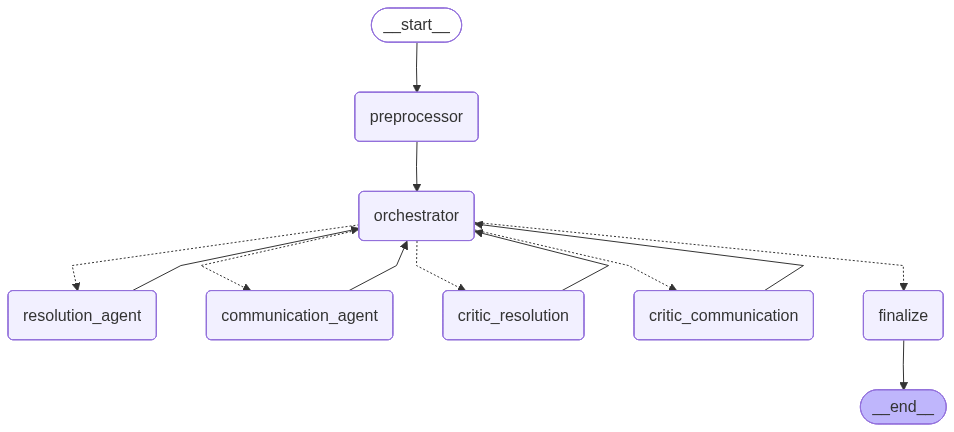

In [58]:
# Visualize the multi-agent workflow graph
try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    # Fallback: print the graph structure as text
    print("Graph visualization requires additional dependencies.")
    print("Workflow nodes:", [n for n in app.get_graph().nodes])
    print(f"Error: {e}")

# **Evaluation Metrics**

We now define the evaluation metrics for the multi-agent system.

## Task Completion Rate

This function computes task completion for a single shipment by checking three sub-criteria:
- whether the exception classification matches ground truth,
- whether the resolution action is correct, and
- whether the communication tone is appropriate.

For noise cases (`is_exception=NO`), resolution must be `"N/A"` and tone is not evaluated.

A task is complete ONLY when ALL three sub-criteria pass.

In [59]:
def compute_task_completion(gt: dict, pred: dict) -> dict:
    """Compute task completion for a single shipment."""
    res = pred.get("resolution_output", {})
    comm = pred.get("communication_output", {})

    # Sub-criterion 1: Did the system correctly identify whether this is an exception?
    exception_correct = gt.get("is_exception") == res.get("is_exception")

    if gt.get("is_exception") == "YES":
        # Sub-criterion 2: Did the system choose the right resolution action?
        resolution_correct = gt.get("expected_resolution") == res.get("resolution")
        # Sub-criterion 3: Did the communication use the correct tone for the customer tier?
        tone_correct = gt.get("expected_tone") == comm.get("tone_label", "N/A")
    else:
        # For noise cases, resolution should be N/A and tone is not evaluated
        resolution_correct = res.get("resolution") in ("N/A", None, "")
        tone_correct = True

    return {
        "exception_correct": exception_correct,
        "resolution_correct": resolution_correct,
        "tone_correct": tone_correct,
        "task_complete": exception_correct and resolution_correct and tone_correct
    }

## Escalation Accuracy

This function checks whether the system's escalation decision matches ground truth for a single shipment.
- Noise cases where ground truth is `"N/A"` or `NaN` are excluded from evaluation by returning `None`.
- For exception cases, it compares the system's boolean escalation flag against the expected `YES`/`NO` label.

In [60]:
def compute_escalation_accuracy(gt: dict, pred: dict) -> bool:
    """Check if escalation decision matches ground truth for a single shipment."""
    # Noise cases have no escalation expectation - skip evaluation
    if gt.get("should_escalate") not in ("YES", "NO"):
        return None

    # Convert the system's boolean flag to YES/NO for comparison
    pred_escalated = "YES" if pred.get("escalated", False) else "NO"

    # Compare against ground truth
    return gt.get("should_escalate") == pred_escalated

## Tool Call Accuracy

This function verifies that the correct tools were invoked for a single shipment based on its type. Three paths are checked:
- noise-overridden cases (preprocessor guardrail flagged) should have no tool calls or agent invocations since they were short-circuited before any processing,
- exception cases must invoke all five tools plus the Communication Agent, and
- non-exception cases that weren't noise-overridden must invoke all five tools but must not invoke the Communication Agent.

In [61]:
def compute_tool_call_accuracy(gt: dict, pred: dict) -> bool:
    """Check if correct tools were invoked for a single shipment."""
    # Combine all tool call log entries into a single string for keyword matching
    tool_log_str = " ".join(pred.get("tool_calls_log", []))
    is_exception = gt.get("is_exception", "NO")
    noise_override = pred.get("noise_override", False)

    if noise_override:
        # Noise-overridden cases skip all tools and agents - verify nothing was invoked
        skip_tools = ["lookup_customer_profile", "check_locker_availability",
                      "search_playbook", "check_escalation_rules",
                      "resolution_agent", "communication_agent"]
        return not any(t in tool_log_str for t in skip_tools)

    # Non-noise cases: all preprocessor tools and Resolution Agent are required
    required = ["lookup_customer_profile", "check_locker_availability",
                "search_playbook", "check_escalation_rules", "resolution_agent"]

    # Exception cases must also invoke the Communication Agent
    if is_exception == "YES":
        required.append("communication_agent")

    all_present = all(t in tool_log_str for t in required)

    # Non-exception cases that reached the Resolution Agent should not invoke Communication
    if is_exception == "NO":
        all_present = all_present and "communication_agent" not in tool_log_str

    return all_present

## Reasoning Trajectory Coherence

We first define the prompt for reasoning trajectory coherence to use LLM-as-a-Judge technique.

- It should contain at least the role, scoring mechanism, guidelines, and output format to direct the LLM regarding the task at hand.
- Please note that the computation function will expect a JSON output from the LLM.

In [62]:
REASONING_TRAJECTORY_COHERENCE_PROMPT = """
You are an evaluation judge assessing the reasoning coherence of a multi-agent
delivery exception handling system.

## Scoring Rubric (1-5)
- 5 (Excellent): All decisions logically consistent. Classification, resolution,
  communication, and critic decisions form a coherent chain with clear rationale.
- 4 (Good): Mostly consistent with minor reasoning gaps. Overall flow is logical.
- 3 (Adequate): Some inconsistencies between agent decisions, but final outcome
  is reasonable.
- 2 (Poor): Significant inconsistencies - resolution contradicts event data,
  tone mismatches tier, or critic decisions are unjustified.
- 1 (Incoherent): Decisions are contradictory or nonsensical.

## Evaluation Criteria
- Does the exception classification match the delivery event details?
- Is the resolution action appropriate for the exception type and customer context?
- Are critic decisions (ACCEPT/REVISE/ESCALATE) justified by the context?
- If revisions occurred, did they improve the resolution?
- Is the communication tone consistent with the customer tier?
- Does the trajectory log show a logical progression of decisions?

## Output Format
Respond with ONLY a JSON object (no markdown, no extra text):
{"score": <integer 1-5>, "justification": "<brief explanation>"}
"""

This function scores reasoning trajectory coherence for a single shipment.
- Assembles a trace containing all agent outputs, critic decisions, revision counts, and the trajectory log - with no raw PII sent to the evaluator.
- Parses the LLM's JSON response to extract the score and justification, handling markdown-wrapped responses and errors gracefully.

In [63]:
def compute_coherence_score(pred: dict) -> dict:
    """Use eval_llm (gpt-4o) to score reasoning trajectory coherence."""
    # Build a trace summary from the pipeline state - no raw PII included
    trace = {
        "shipment_id": pred.get("shipment_id"),
        "consolidated_event": pred.get("consolidated_event", {}),
        "customer_tier": pred.get("customer_profile", {}).get("tier"),
        "escalation_signals": pred.get("escalation_signals", {}),
        "resolution_output": pred.get("resolution_output", {}),
        "critic_resolution_output": pred.get("critic_resolution_output", {}),
        "resolution_revision_count": pred.get("resolution_revision_count", 0),
        "communication_output": pred.get("communication_output", {}),
        "critic_communication_output": pred.get("critic_communication_output", {}),
        "trajectory_log": pred.get("trajectory_log", [])
    }

    try:
        # Invoke the evaluation judge
        response = eval_llm.invoke([
            SystemMessage(content=REASONING_TRAJECTORY_COHERENCE_PROMPT),
            HumanMessage(content=json.dumps(trace, indent=2))
        ])

        # Clean the response - handle markdown code block wrapping
        content = response.content.strip()
        if content.startswith("```"):
            content = content.split("\n", 1)[1].rsplit("```", 1)[0].strip()

        # Parse the JSON response
        parsed = json.loads(content)
        return {
            "score": parsed.get("score", 0),
            "justification": parsed.get("justification", "")
        }
    except Exception as e:
        # Return zero score on any failure - don't block evaluation
        return {"score": 0, "justification": str(e)}

## Helper Function for Single Test Case Metrics

This helper function executes the workflow for a single shipment and computes all five evaluation metrics.
- Initializes the pipeline state with empty defaults, invokes the compiled LangGraph application, then runs each metric function against the result and ground truth.
- Also extracts playbook page citations for the test case output.

In [64]:
def run_single_test_case(shipment_id: str, rows: list[dict], gt: dict) -> dict:
    """Execute the pipeline for a single shipment and compute all metrics."""
    # Initialize pipeline state with empty defaults for all fields
    initial_state = {
        "raw_rows": rows,
        "shipment_id": shipment_id,
        "consolidated_event": {},
        "customer_profile": {},
        "customer_profile_full": {},
        "locker_availability": [],
        "playbook_context": [],
        "escalation_signals": {},
        "resolution_output": {},
        "critic_resolution_output": {},
        "resolution_revision_count": 0,
        "critic_feedback": "",
        "communication_output": {},
        "critic_communication_output": {},
        "next_agent": "",
        "max_loops": 2,                                                          # Maximum REVISE loops before forced escalation
        "escalated": False,
        "tool_calls_log": [],
        "trajectory_log": [],
        "start_time": None,
        "latency_sec": None,
        "final_actions": [],
        "noise_override": False,
        "guardrail_triggered": False
    }

    # Run the full pipeline
    result = app.invoke(initial_state, config={"configurable": {"thread_id": shipment_id}})

    # Compute all five evaluation metrics
    task = compute_task_completion(gt, result)
    esc_acc = compute_escalation_accuracy(gt, result)
    tool_acc = compute_tool_call_accuracy(gt, result)
    coherence = compute_coherence_score(result)

    # Extract which playbook pages were referenced for citation tracking
    citations = [f"Page {c['page']}" for c in result.get("playbook_context", [])]

    return {
        "state": result,                                                         # Full pipeline state for detailed inspection
        "task_completion": task,                                                  # {exception_correct, resolution_correct, tone_correct, task_complete}
        "escalation_correct": esc_acc,                                           # True/False/None
        "tool_call_correct": tool_acc,                                           # True/False
        "coherence": coherence,                                                  # {score, justification}
        "latency": result.get("latency_sec", 0.0),                              # End-to-end seconds
        "citations": citations                                                   # Playbook pages referenced
    }

# **Test Cases**

## Prepare Ground Truth

We prepares the test case inputs.
- Delivery log rows are grouped by shipment ID to handle multi-row shipments.
- Ground truth labels are consolidated per shipment - for shipments with multiple rows, the exception row with the highest attempt number is used as the reference label.
- Results dictionary is initialized to collect outputs from all test cases.

In [65]:
# Read all delivery logs and group rows by shipment ID
all_logs = read_delivery_logs.invoke({})
shipment_groups = defaultdict(list)
for row in all_logs:
    shipment_groups[row["shipment_id"]].append(row)

# Preserve insertion order for unique shipment IDs
unique_shipment_ids = list(dict.fromkeys(row["shipment_id"] for row in all_logs))

# Build consolidated ground truth - one label per shipment
gt_by_shipment = defaultdict(list)
for _, row in ground_truth_df.iterrows():
    gt_by_shipment[row["shipment_id"]].append(row.to_dict())

# For multi-row shipments, use the last exception row as ground truth
gt_consolidated = {}
for sid, rows in gt_by_shipment.items():
    exc_rows = [r for r in rows if r["is_exception"] == "YES"]
    gt_consolidated[sid] = exc_rows[-1] if exc_rows else rows[0]

print(f"Shipments to process: {unique_shipment_ids}")

# Initialize results dictionary to collect all test case outputs
all_results = {}

Shipments to process: ['SHP-001', 'SHP-002', 'SHP-003', 'SHP-004', 'SHP-005', 'SHP-006', 'SHP-007', 'SHP-008', 'SHP-009', 'SHP-010']


## Helper Function for Test Case Runs

This helper function prints the complete output for a single test case
- predictions versus ground truth,
- all five evaluation metrics,
- the full agent trajectory trace,
- playbook page citations, and
- a preview of the customer message if one was generated.

In [66]:
def print_test_case_output(sid: str, result: dict, gt: dict) -> None:
    """Print a single test case result."""
    state = result["state"]
    res = state.get("resolution_output", {})
    comm = state.get("communication_output", {})
    tc = result["task_completion"]

    # --- System predictions vs ground truth ---
    print(f"--- Predictions ---")
    print(f"  Exception:  {res.get('is_exception', 'N/A')} (GT: {gt.get('is_exception')})")
    print(f"  Resolution: {res.get('resolution', 'N/A')} (GT: {gt.get('expected_resolution')})")
    pred_esc = 'YES' if state.get('escalated') else 'NO'
    print(f"  Escalated:  {pred_esc} (GT: {gt.get('should_escalate')})")
    print(f"  Tone:       {comm.get('tone_label', 'N/A')} (GT: {gt.get('expected_tone')})")
    print(f"  Revisions:  {state.get('resolution_revision_count', 0)}")
    print(f"  Guardrail:  {'TRIGGERED' if state.get('guardrail_triggered') else 'CLEAR'}")

    # --- Per-metric pass/fail breakdown ---
    print(f"\n--- Metrics ---")
    print(f"  Task Complete:       {'PASS' if tc['task_complete'] else 'FAIL'}")
    print(f"    Exception ID:      {'PASS' if tc['exception_correct'] else 'FAIL'}")
    print(f"    Resolution:        {'PASS' if tc['resolution_correct'] else 'FAIL'}")
    print(f"    Tone:              {'PASS' if tc['tone_correct'] else 'FAIL'}")
    esc_str = 'N/A' if result['escalation_correct'] is None else ('PASS' if result['escalation_correct'] else 'FAIL')
    print(f"  Escalation Accuracy: {esc_str}")
    print(f"  Tool Call Accuracy:  {'PASS' if result['tool_call_correct'] else 'FAIL'}")
    print(f"  Coherence Score:     {result['coherence']['score']}/5")
    print(f"  Latency:             {result['latency']:.2f}s")

    # --- Full agent decision trail ---
    print(f"\n--- Trajectory ---")
    for entry in state.get("trajectory_log", []):
        print(f"  {entry}")

    # --- Which playbook pages were retrieved ---
    print(f"\n--- Document Citations ---")
    print(f"  Playbook pages referenced: {', '.join(result['citations']) if result['citations'] else 'None'}")

    # --- Preview of the customer notification if generated ---
    if comm.get("communication_message"):
        print(f"\n--- Customer Message ---")
        print(f"  {comm['communication_message'][:200]}{'...' if len(comm.get('communication_message','')) > 200 else ''}")

## Test Case 1: SHP-001 - Successful Delivery (Noise Filtering)

In [67]:
sid = unique_shipment_ids[0]
rows = shipment_groups[sid]
gt = gt_consolidated[sid]
result = run_single_test_case(sid, rows, gt)
all_results[sid] = result
print_test_case_output(sid, result, gt)

--- Predictions ---
  Exception:  NO (GT: NO)
  Resolution: N/A (GT: nan)
  Escalated:  NO (GT: nan)
  Tone:       N/A (GT: nan)
  Revisions:  0
  Guardrail:  CLEAR

--- Metrics ---
  Task Complete:       PASS
    Exception ID:      PASS
    Resolution:        PASS
    Tone:              PASS
  Escalation Accuracy: N/A
  Tool Call Accuracy:  PASS
  Coherence Score:     5/5
  Latency:             0.01s

--- Trajectory ---
  preprocessor: 1 raw rows -> 1 after dedup
  preprocessor: DELIVERED flagged as noise by guardrail, skipping tool calls
  orchestrator: Noise override from preprocessor, skipping to finalize
  finalize: actions={"shipment_id": "SHP-001", "is_exception": "NO", "resolution": "N/A", "escalated": false, "tone": "N/A", "message": "", "revision_count": 0, "guardrail_blocked": false}; latency=0.010s

--- Document Citations ---
  Playbook pages referenced: None


## Test Case 2: SHP-002 - VIP Multi-Attempt with Duplicate Scan

In [68]:
sid = unique_shipment_ids[1]
rows = shipment_groups[sid]
gt = gt_consolidated[sid]
result = run_single_test_case(sid, rows, gt)
all_results[sid] = result
print_test_case_output(sid, result, gt)

--- Predictions ---
  Exception:  YES (GT: YES)
  Resolution: RESCHEDULE (GT: RESCHEDULE)
  Escalated:  YES (GT: YES)
  Tone:       FORMAL (GT: FORMAL)
  Revisions:  0
  Guardrail:  CLEAR

--- Metrics ---
  Task Complete:       PASS
    Exception ID:      PASS
    Resolution:        PASS
    Tone:              PASS
  Escalation Accuracy: PASS
  Tool Call Accuracy:  PASS
  Coherence Score:     5/5
  Latency:             11.61s

--- Trajectory ---
  preprocessor: 3 raw rows -> 2 after dedup
  resolution_agent: is_exception=YES, resolution=RESCHEDULE
  critic_resolution: decision=ESCALATE
  orchestrator: Forced escalation from rule engine - ['AUTOMATIC: VIP customer with 5 exceptions in 90d (>=3)']
  communication_agent: tone=FORMAL
  orchestrator: Forced escalation from rule engine - ['AUTOMATIC: VIP customer with 5 exceptions in 90d (>=3)']
  critic_communication: decision=ACCEPT
  orchestrator: Forced escalation from rule engine - ['AUTOMATIC: VIP customer with 5 exceptions in 90d (>=3

## Test Case 3: SHP-003 - Address Not Found (Standard Customer)

In [69]:
sid = unique_shipment_ids[2]
rows = shipment_groups[sid]
gt = gt_consolidated[sid]
result = run_single_test_case(sid, rows, gt)
all_results[sid] = result
print_test_case_output(sid, result, gt)

--- Predictions ---
  Exception:  YES (GT: YES)
  Resolution: RESCHEDULE (GT: RESCHEDULE)
  Escalated:  NO (GT: NO)
  Tone:       CASUAL (GT: CASUAL)
  Revisions:  0
  Guardrail:  CLEAR

--- Metrics ---
  Task Complete:       PASS
    Exception ID:      PASS
    Resolution:        PASS
    Tone:              PASS
  Escalation Accuracy: PASS
  Tool Call Accuracy:  PASS
  Coherence Score:     5/5
  Latency:             8.99s

--- Trajectory ---
  preprocessor: 1 raw rows -> 1 after dedup
  resolution_agent: is_exception=YES, resolution=RESCHEDULE
  critic_resolution: decision=ACCEPT
  communication_agent: tone=CASUAL
  critic_communication: decision=ACCEPT
  finalize: actions={"shipment_id": "SHP-003", "is_exception": "YES", "resolution": "RESCHEDULE", "escalated": false, "tone": "CASUAL", "message": "Hey David! We ran into a little hiccup with your delivery because we couldn't find building 999 on Oak Avenue. No worries though, we just need to reschedule it. Can you confirm or update yo

## Test Case 4: SHP-004 - Damaged Fragile Package (VIP Escalation)

In [70]:
sid = unique_shipment_ids[3]
rows = shipment_groups[sid]
gt = gt_consolidated[sid]
result = run_single_test_case(sid, rows, gt)
all_results[sid] = result
print_test_case_output(sid, result, gt)

--- Predictions ---
  Exception:  YES (GT: YES)
  Resolution: REPLACE (GT: REPLACE)
  Escalated:  YES (GT: YES)
  Tone:       FORMAL (GT: FORMAL)
  Revisions:  0
  Guardrail:  CLEAR

--- Metrics ---
  Task Complete:       PASS
    Exception ID:      PASS
    Resolution:        PASS
    Tone:              PASS
  Escalation Accuracy: PASS
  Tool Call Accuracy:  PASS
  Coherence Score:     5/5
  Latency:             7.74s

--- Trajectory ---
  preprocessor: 1 raw rows -> 1 after dedup
  resolution_agent: is_exception=YES, resolution=REPLACE
  critic_resolution: decision=ACCEPT
  orchestrator: Forced escalation from rule engine - ['AUTOMATIC: VIP customer with 4 exceptions in 90d (>=3)']
  communication_agent: tone=FORMAL
  orchestrator: Forced escalation from rule engine - ['AUTOMATIC: VIP customer with 4 exceptions in 90d (>=3)']
  critic_communication: decision=ACCEPT
  orchestrator: Forced escalation from rule engine - ['AUTOMATIC: VIP customer with 4 exceptions in 90d (>=3)']
  finali

## Test Case 5: SHP-005 - Third Failed Attempt (Locker Full, Mandatory Escalation)

In [71]:
sid = unique_shipment_ids[4]
rows = shipment_groups[sid]
gt = gt_consolidated[sid]
result = run_single_test_case(sid, rows, gt)
all_results[sid] = result
print_test_case_output(sid, result, gt)

--- Predictions ---
  Exception:  YES (GT: YES)
  Resolution: REROUTE_TO_LOCKER (GT: REROUTE_TO_LOCKER)
  Escalated:  YES (GT: YES)
  Tone:       CASUAL (GT: CASUAL)
  Revisions:  0
  Guardrail:  CLEAR

--- Metrics ---
  Task Complete:       PASS
    Exception ID:      PASS
    Resolution:        PASS
    Tone:              PASS
  Escalation Accuracy: PASS
  Tool Call Accuracy:  PASS
  Coherence Score:     5/5
  Latency:             8.96s

--- Trajectory ---
  preprocessor: 1 raw rows -> 1 after dedup
  resolution_agent: is_exception=YES, resolution=REROUTE_TO_LOCKER
  critic_resolution: decision=ESCALATE
  orchestrator: Forced escalation from rule engine - ['AUTOMATIC: 3rd failed delivery attempt']
  orchestrator: Escalation from discretionary triggers - ['DISCRETIONARY: Standard customer with 6 exceptions in 90d (>5)']
  communication_agent: tone=CASUAL
  orchestrator: Forced escalation from rule engine - ['AUTOMATIC: 3rd failed delivery attempt']
  orchestrator: Escalation from disc

## Test Case 6: SHP-006 - Refused Delivery (Return to Sender)

In [72]:
sid = unique_shipment_ids[5]
rows = shipment_groups[sid]
gt = gt_consolidated[sid]
result = run_single_test_case(sid, rows, gt)
all_results[sid] = result
print_test_case_output(sid, result, gt)

--- Predictions ---
  Exception:  YES (GT: YES)
  Resolution: RETURN_TO_SENDER (GT: RETURN_TO_SENDER)
  Escalated:  NO (GT: NO)
  Tone:       CASUAL (GT: CASUAL)
  Revisions:  0
  Guardrail:  CLEAR

--- Metrics ---
  Task Complete:       PASS
    Exception ID:      PASS
    Resolution:        PASS
    Tone:              PASS
  Escalation Accuracy: PASS
  Tool Call Accuracy:  PASS
  Coherence Score:     5/5
  Latency:             8.35s

--- Trajectory ---
  preprocessor: 1 raw rows -> 1 after dedup
  resolution_agent: is_exception=YES, resolution=RETURN_TO_SENDER
  critic_resolution: decision=ACCEPT
  communication_agent: tone=CASUAL
  critic_communication: decision=ACCEPT
  finalize: actions={"shipment_id": "SHP-006", "is_exception": "YES", "resolution": "RETURN_TO_SENDER", "escalated": false, "tone": "CASUAL", "message": "Hey Michael! It looks like your delivery was refused because you mentioned you didn\u2019t order it. No worries, we\u2019ll be returning the package to the sender. I

## Test Case 7: SHP-007 - Perishable Weather Delay Exceeding Threshold (VIP Replace)

In [73]:
sid = unique_shipment_ids[6]
rows = shipment_groups[sid]
gt = gt_consolidated[sid]
result = run_single_test_case(sid, rows, gt)
all_results[sid] = result
print_test_case_output(sid, result, gt)

--- Predictions ---
  Exception:  YES (GT: YES)
  Resolution: REPLACE (GT: REPLACE)
  Escalated:  YES (GT: YES)
  Tone:       FORMAL (GT: FORMAL)
  Revisions:  0
  Guardrail:  CLEAR

--- Metrics ---
  Task Complete:       PASS
    Exception ID:      PASS
    Resolution:        PASS
    Tone:              PASS
  Escalation Accuracy: PASS
  Tool Call Accuracy:  PASS
  Coherence Score:     5/5
  Latency:             12.77s

--- Trajectory ---
  preprocessor: 2 raw rows -> 1 after dedup
  resolution_agent: is_exception=YES, resolution=REPLACE
  critic_resolution: decision=ACCEPT
  orchestrator: Forced escalation from rule engine - ['AUTOMATIC: Perishable with 5.0hr delay (>4hr threshold)']
  communication_agent: tone=FORMAL
  orchestrator: Forced escalation from rule engine - ['AUTOMATIC: Perishable with 5.0hr delay (>4hr threshold)']
  critic_communication: decision=ACCEPT
  orchestrator: Forced escalation from rule engine - ['AUTOMATIC: Perishable with 5.0hr delay (>4hr threshold)']
  fi

## Test Case 8: SHP-008 - Discretionary Escalation (High Exception History)

In [74]:
sid = unique_shipment_ids[7]
rows = shipment_groups[sid]
gt = gt_consolidated[sid]
result = run_single_test_case(sid, rows, gt)
all_results[sid] = result
print_test_case_output(sid, result, gt)

--- Predictions ---
  Exception:  YES (GT: YES)
  Resolution: RESCHEDULE (GT: RESCHEDULE)
  Escalated:  YES (GT: YES)
  Tone:       CASUAL (GT: CASUAL)
  Revisions:  0
  Guardrail:  CLEAR

--- Metrics ---
  Task Complete:       PASS
    Exception ID:      PASS
    Resolution:        PASS
    Tone:              PASS
  Escalation Accuracy: PASS
  Tool Call Accuracy:  PASS
  Coherence Score:     5/5
  Latency:             9.01s

--- Trajectory ---
  preprocessor: 1 raw rows -> 1 after dedup
  resolution_agent: is_exception=YES, resolution=RESCHEDULE
  critic_resolution: decision=ESCALATE
  orchestrator: Escalation from discretionary triggers - ['DISCRETIONARY: Standard customer with 6 exceptions in 90d (>5)']
  communication_agent: tone=CASUAL
  orchestrator: Escalation from discretionary triggers - ['DISCRETIONARY: Standard customer with 6 exceptions in 90d (>5)']
  critic_communication: decision=ACCEPT
  orchestrator: Escalation from discretionary triggers - ['DISCRETIONARY: Standard cu

## Test Case 9: SHP-009 - Severely Damaged Perishable (Premium Replace)

In [75]:
sid = unique_shipment_ids[8]
rows = shipment_groups[sid]
gt = gt_consolidated[sid]
result = run_single_test_case(sid, rows, gt)
all_results[sid] = result
print_test_case_output(sid, result, gt)

--- Predictions ---
  Exception:  YES (GT: YES)
  Resolution: REPLACE (GT: REPLACE)
  Escalated:  YES (GT: YES)
  Tone:       FORMAL (GT: FORMAL)
  Revisions:  0
  Guardrail:  CLEAR

--- Metrics ---
  Task Complete:       PASS
    Exception ID:      PASS
    Resolution:        PASS
    Tone:              PASS
  Escalation Accuracy: PASS
  Tool Call Accuracy:  PASS
  Coherence Score:     5/5
  Latency:             9.36s

--- Trajectory ---
  preprocessor: 1 raw rows -> 1 after dedup
  resolution_agent: is_exception=YES, resolution=REPLACE
  critic_resolution: decision=ACCEPT
  orchestrator: Forced escalation from rule engine - ['AUTOMATIC: Damaged perishable package']
  communication_agent: tone=FORMAL
  orchestrator: Forced escalation from rule engine - ['AUTOMATIC: Damaged perishable package']
  critic_communication: decision=ACCEPT
  orchestrator: Forced escalation from rule engine - ['AUTOMATIC: Damaged perishable package']
  finalize: actions={"shipment_id": "SHP-009", "is_exceptio

## Test Case 10: SHP-010 - Routine Depot Scan (Noise Filtering)

In [76]:
sid = unique_shipment_ids[9]
rows = shipment_groups[sid]
gt = gt_consolidated[sid]
result = run_single_test_case(sid, rows, gt)
all_results[sid] = result
print_test_case_output(sid, result, gt)

--- Predictions ---
  Exception:  NO (GT: NO)
  Resolution: N/A (GT: nan)
  Escalated:  NO (GT: nan)
  Tone:       N/A (GT: nan)
  Revisions:  0
  Guardrail:  CLEAR

--- Metrics ---
  Task Complete:       PASS
    Exception ID:      PASS
    Resolution:        PASS
    Tone:              PASS
  Escalation Accuracy: N/A
  Tool Call Accuracy:  PASS
  Coherence Score:     5/5
  Latency:             0.01s

--- Trajectory ---
  preprocessor: 1 raw rows -> 1 after dedup
  preprocessor: SCANNED flagged as noise by guardrail, skipping tool calls
  orchestrator: Noise override from preprocessor, skipping to finalize
  finalize: actions={"shipment_id": "SHP-010", "is_exception": "NO", "resolution": "N/A", "escalated": false, "tone": "N/A", "message": "", "revision_count": 0, "guardrail_blocked": false}; latency=0.007s

--- Document Citations ---
  Playbook pages referenced: None


# **Aggregated Evaluation Metrics**

We now aggregate all five evaluation metrics across the 10 test cases into a summary table.

- Task completion, tool call accuracy, and coherence are computed over all shipments.
- Escalation accuracy excludes noise cases where ground truth is `"N/A"`.
- Latency is reported as the mean across all runs.

In [77]:
# Compute and display aggregate evaluation metrics
n = len(all_results)

task_complete_count = sum(1 for r in all_results.values() if r["task_completion"]["task_complete"])
exception_correct = sum(1 for r in all_results.values() if r["task_completion"]["exception_correct"])
resolution_correct = sum(1 for r in all_results.values() if r["task_completion"]["resolution_correct"])
tone_correct = sum(1 for r in all_results.values() if r["task_completion"]["tone_correct"])
tool_correct = sum(1 for r in all_results.values() if r["tool_call_correct"])

esc_results = [r["escalation_correct"] for r in all_results.values() if r["escalation_correct"] is not None]
esc_correct = sum(1 for e in esc_results if e)

coherence_scores = [r["coherence"]["score"] for r in all_results.values()]
avg_coherence = statistics.mean(coherence_scores) if coherence_scores else 0.0
avg_latency = statistics.mean(r["latency"] for r in all_results.values())

print("=" * 60)
print("AGGREGATE EVALUATION METRICS")
print("=" * 60)
print(f"Task Completion:      {task_complete_count}/{n} ({task_complete_count/n:.0%})")
print(f"  Exception Detection:  {exception_correct}/{n} ({exception_correct/n:.0%})")
print(f"  Resolution Accuracy:  {resolution_correct}/{n} ({resolution_correct/n:.0%})")
print(f"  Tone Accuracy:        {tone_correct}/{n} ({tone_correct/n:.0%})")
print(f"Tool Call Accuracy:   {tool_correct}/{n} ({tool_correct/n:.0%})")
if esc_results:
    print(f"Escalation Accuracy:  {esc_correct}/{len(esc_results)} ({esc_correct/len(esc_results):.0%})")
else:
    print("Escalation Accuracy:  N/A (no applicable cases)")
print(f"Avg Coherence Score:  {avg_coherence:.2f}/5")
print(f"Avg Latency:          {avg_latency:.2f}s")
print("=" * 60)

AGGREGATE EVALUATION METRICS
Task Completion:      10/10 (100%)
  Exception Detection:  10/10 (100%)
  Resolution Accuracy:  10/10 (100%)
  Tone Accuracy:        10/10 (100%)
Tool Call Accuracy:   10/10 (100%)
Escalation Accuracy:  8/8 (100%)
Avg Coherence Score:  5.00/5
Avg Latency:          7.68s


We print the detailed per-shipment results showing ground truth versus predictions for each evaluation dimension, along with pass/fail status for task completion and tool calls, the coherence score, and latency.

This provides a complete at-a-glance view of where the system succeeded and where it diverged.

In [78]:
# Print detailed results for all test cases
for sid in unique_shipment_ids:
    if sid in all_results:
        gt = gt_consolidated[sid]
        print_test_case_output(sid, all_results[sid], gt)
        print()

--- Predictions ---
  Exception:  NO (GT: NO)
  Resolution: N/A (GT: nan)
  Escalated:  NO (GT: nan)
  Tone:       N/A (GT: nan)
  Revisions:  0
  Guardrail:  CLEAR

--- Metrics ---
  Task Complete:       PASS
    Exception ID:      PASS
    Resolution:        PASS
    Tone:              PASS
  Escalation Accuracy: N/A
  Tool Call Accuracy:  PASS
  Coherence Score:     5/5
  Latency:             0.01s

--- Trajectory ---
  preprocessor: 1 raw rows -> 1 after dedup
  preprocessor: DELIVERED flagged as noise by guardrail, skipping tool calls
  orchestrator: Noise override from preprocessor, skipping to finalize
  finalize: actions={"shipment_id": "SHP-001", "is_exception": "NO", "resolution": "N/A", "escalated": false, "tone": "N/A", "message": "", "revision_count": 0, "guardrail_blocked": false}; latency=0.010s

--- Document Citations ---
  Playbook pages referenced: None

--- Predictions ---
  Exception:  YES (GT: YES)
  Resolution: RESCHEDULE (GT: RESCHEDULE)
  Escalated:  YES (GT: YE

Finally, we close the database connection.

In [79]:
db_conn.close()

# **Conclusions and Business Recommendations**

## Conclusions

This proof of concept demonstrates that a multi-agent AI architecture can automate the full last-mile delivery exception handling pipeline — from raw event ingestion through resolution, customer notification, and audit — with measurable accuracy and consistency.

**Key achievements:**

- **End-to-end automation of a manually intensive workflow.** The system ingests noisy, duplicated delivery logs; deduplicates and consolidates multi-row shipment events; classifies exceptions; determines resolution actions; generates personalized customer communications; and produces auditable decision traces — all without human intervention on the happy path.

- **Structured multi-agent collaboration with built-in quality gates.** The LangGraph pipeline separates concerns across specialized agents (preprocessor, orchestrator, resolution, communication) with dedicated critic agents that validate each decision against playbook rules before it proceeds. This separation mirrors how high-performing operations teams work — specialist judgment with peer review — but at machine speed.

- **Policy-faithful decision-making grounded in retrieval-augmented generation.** Resolution decisions are anchored to the operator’s own exception resolution playbook via semantic search over a ChromaDB vector store, reducing hallucination risk and ensuring that automated actions align with existing operational policies rather than replacing them.

- **Nuanced, context-aware handling across diverse exception types.** The system correctly differentiates between scenarios that require fundamentally different responses — a VIP customer’s perishable package delayed by weather versus a standard customer’s first failed attempt on a non-perishable item — by reasoning over customer tier, package attributes, delivery history, locker availability, and escalation thresholds simultaneously.

- **Automated escalation with rule-engine authority.** Supervisor escalation is triggered by an explicit rule engine evaluating quantitative thresholds (attempt counts, exception frequency, damage severity), not by subjective LLM judgment alone. This prevents both missed escalations on critical cases and unnecessary escalations that waste supervisor capacity.

- **Quantitative evaluation across five dimensions.** The system is benchmarked against curated ground truth across task completion (exception detection, resolution accuracy, tone accuracy), escalation accuracy, tool call correctness, reasoning trajectory coherence, and end-to-end latency — providing a rigorous, repeatable basis for assessing production readiness.

## Business Recommendations

**Near-term (0–3 months) — Validate and harden the POC:**

- **Run the system on a broader exception dataset.** Expand the test suite beyond 10 curated shipments to include 200–500 historical exceptions sampled from production logs. Measure accuracy degradation and identify exception categories that require additional playbook coverage or prompt refinement before scaling.

- **Integrate with live delivery feeds for shadow-mode deployment.** Connect the pipeline to real-time shipment status events in read-only mode — the system processes exceptions and logs decisions alongside human operators without taking action. Compare automated recommendations against actual human decisions to quantify agreement rate, time savings, and cases where the AI catches issues humans miss.

- **Establish feedback loops with operations supervisors.** Build a lightweight review interface where supervisors can approve, override, or annotate AI-generated resolutions on escalated cases. Use this feedback to fine-tune prompts, update playbook rules, and expand the ground truth dataset for ongoing evaluation.

**Medium-term (3–6 months) — Scale and operationalize:**

- **Deploy in assisted mode on high-confidence exception types.** Start with exception categories where the POC achieved the highest accuracy (e.g., straightforward failed attempts, clear damage cases). Let the system execute resolutions autonomously on these while keeping human-in-the-loop for ambiguous or novel scenarios.

- **Expand the exception taxonomy.** Extend the playbook and agent prompts to cover additional exception types common in real operations: customs holds, address correction requests, partial deliveries, and carrier handoff failures. Each new category should be added with corresponding ground truth test cases.

- **Integrate customer communication with existing notification infrastructure.** Connect the communication agent’s output to the retailer’s email, SMS, and push notification systems to close the loop from decision to customer-facing action — eliminating the last manual handoff in the pipeline.

**Long-term (6–12 months) — Maximize business impact:**

- **Extend to multi-region and multi-carrier operations.** Adapt the system to handle region-specific policies, carrier-specific status codes, and localized customer communication requirements. The modular agent architecture supports this by isolating policy logic in the playbook and carrier-specific parsing in the preprocessor.

- **Build a continuous improvement engine.** Use production decision logs, supervisor feedback, and customer satisfaction signals to automatically identify underperforming resolution patterns and trigger playbook updates — creating a self-improving system that gets more accurate over time.

- **Quantify ROI and build the business case for full-scale rollout.** Track key metrics from pilot operations — reduction in mean exception resolution time, decrease in unnecessary truck rolls and spoilage write-offs, improvement in escalation precision, and change in customer retention rates for exception-affected shipments — to build a data-backed justification for enterprise-wide deployment.

<font size=6 color='#4682B4'>Power Ahead</font>
___